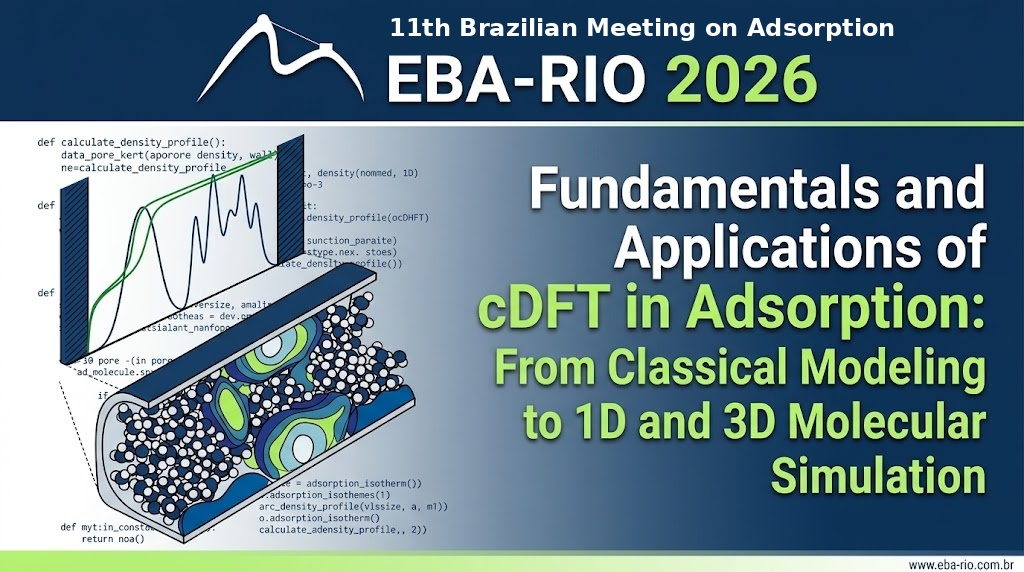


# cDFT applied to adsorption with PyDFTlj

**Hands-on course · Google Colab · Revision 6**

One idea guides the class: cDFT extends bulk thermodynamics to a density that varies in space. We will connect this idea to concrete decisions: fluid, functional, force field, grid, solver, and observables.

The **4-hour** pathway covers setup, EOS, 1D profiles, hysteresis, a comparison between 1D Steele and 3D atomistic carbon, and the CIF–MOF case. Grid and RDF extensions and solver and hardware tests are placed at the end. Running all fine-resolution calculations may exceed the duration of the class.

Here DFT is **classical**, not electronic. We work with a fluid species represented by an effective LJ site. Pinned code: [PyDFTlj 1.0.3, commit 16e7d43](https://github.com/elvissoares/PyDFTlj/tree/16e7d4349e22d3ead8774a332011b4c3d21806cd).

## Class roadmap

The parts group learning objectives; the **sections numbered 1 through 19** follow a single sequence. Internal subsections inherit the section number. There are no blocks outside the parts.

| Part | Sections | Suggested time | Outcome |
|---|---|---:|---|
| A — Setup and fundamentals | 1–5 | 0–65 min | Colab, units, EOS, and cDFT setup |
| B — 1D adsorption in carbon | 6–9 | 65–135 min | Steele potential, profiles, and N₂ hysteresis |
| Break | — | 135–145 min | — |
| C — From a 1D slit to a 3D slit | 10 | 145–170 min | ASE slab, LJ summation, and comparison with Steele |
| D — CH₄ in IRMOF-1 | 11–13 | 170–230 min | CIF, potential, density, and isotherm |
| E — Physical and numerical extensions | 14–15 | Guided study | MOF grids and RDF |
| F — Troubleshooting and performance | 16–18 | Guided study | Diagnostics, three solvers, and CPU/GPU |
| G — Application to research | 19 | 230–240 min | Student adaptation plan |

**In-class pathway:** A → B → C → D → G. Parts E and F come after the case studies for reference and extra activities. Times are planning estimates, not execution guarantees.

**Running in Colab:** execute cells in order along the selected pathway. Section 14 depends on the MOF data; section 15 depends only on the imports and the `dados` folder; section 17 reuses `slab_dft` from section 10; section 18 has its own constructor. “Run all” includes expensive extensions. Save a copy before exploring larger grids.

# Part A — Setup and fundamentals

## 1. Setup in Google Colab

1. Open this file in [Google Colab](https://colab.research.google.com/) using **File → Upload notebook**.
2. To use a GPU, open **Runtime → Change runtime type** and select an available GPU under **Hardware accelerator** (for example, T4). Save and reconnect. Menu names may vary with the interface language.
3. Run the installation cell below and then the imports cell. `CUDA available: True` confirms that PyTorch can use the GPU.
4. If the session restarts, repeat the installation and the cells needed to rebuild the objects. Files in `/content` are temporary; download the notebook and results when finished.

CPU works for all examples. GPU is especially useful for the larger 3D grids; availability and memory depend on the Colab session.

The package depends on NumPy, SciPy, pandas, Matplotlib, SciencePlots, and PyTorch. We add **ASE** (CIF and `.cube`), **py3Dmol** (interactive 3D fields), and **xlrd** (reference spreadsheets). Pinning the commit makes the API reproducible. The next cell installs these dependencies.

In [ ]:
%pip -q install "git+https://github.com/elvissoares/PyDFTlj.git@16e7d4349e22d3ead8774a332011b4c3d21806cd" ase py3Dmol xlrd


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 26.1 MB/s eta 0:00:00


We import the libraries and record versions, device, and CUDA availability. This information helps reproduce the results.

In [ ]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
from urllib.request import urlretrieve
import gc
import inspect
import time
import sys
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from pydftlj.dft import DFT
from pydftlj.eos import LJEOS
from pydftlj.optimizer import Optimizer

try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("default")

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.20})

COMMIT = "16e7d4349e22d3ead8774a332011b4c3d21806cd"
RAW = f"https://raw.githubusercontent.com/elvissoares/PyDFTlj/{COMMIT}"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_1D = "cpu"  # Small grids; the hardware comparison is in section 18.
CPU_THREADS = 1    # Adjustable; avoids excess threads for the small FFTs used in class.
torch.set_num_threads(CPU_THREADS)

print("Python:", sys.version.split()[0])
for pacote in ["pydftlj", "numpy", "scipy", "pandas", "matplotlib", "torch", "ase", "py3Dmol"]:
    print(f"{pacote:12s}: {version(pacote)}")
print("PyTorch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Device:", DEVICE)


Python: 3.13.15
pydftlj     : 1.0.3
numpy       : 2.1.3
scipy       : 1.16.3
pandas      : 2.2.3
matplotlib  : 3.10.0
torch       : 2.11.0+cu130
ase         : 3.29.0
py3Dmol     : 2.5.5
PyTorch CUDA: 13.0
CUDA available: True
GPU: Tesla T4
Device: cuda


## 2. First, understand the object being assembled

```text
PyDFTlj/
├── pydftlj/
│   ├── __init__.py
│   ├── dft.py          Grid, fields, functionals, and observables
│   ├── eos.py          Hard-sphere and LJ EOS; vapor–liquid equilibrium
│   ├── optimizer.py    Picard, Anderson, FIRE, and ABC-FIRE
│   └── aux.py          FMT weight functions and Fourier-space LJ kernels
├── examples/
│   ├── Example1...     EOS and phase diagram
│   ├── Example2...     Hard spheres next to a wall
│   ├── Example3...     LJ at a hard wall and in a Steele slit
│   ├── Example4...     Radial distribution function
│   ├── Example5...     CH4 in MOFs
│   ├── Example6...     CH4 in amorphous carbon
│   ├── structures/    CIFs for MOFs and carbons
│   ├── parameters/    DREIDING, UFF, and Steele
│   ├── data/
│   │   ├── MC/        Molecular simulation data (including MC and MD)
│   │   └── experimental/
│   └── figures/       Reference figures
├── dist/              Packaged distributions
├── pyproject.toml     Metadata and dependencies
├── setup.py           Installation
├── README.md          Overview and references
└── LICENSE            GPL-3.0
```

Some older examples use `Set_...` and `ndim`. In this course we use the `snake_case` API from the pinned commit.

### 2.1 Safe calculation sequence

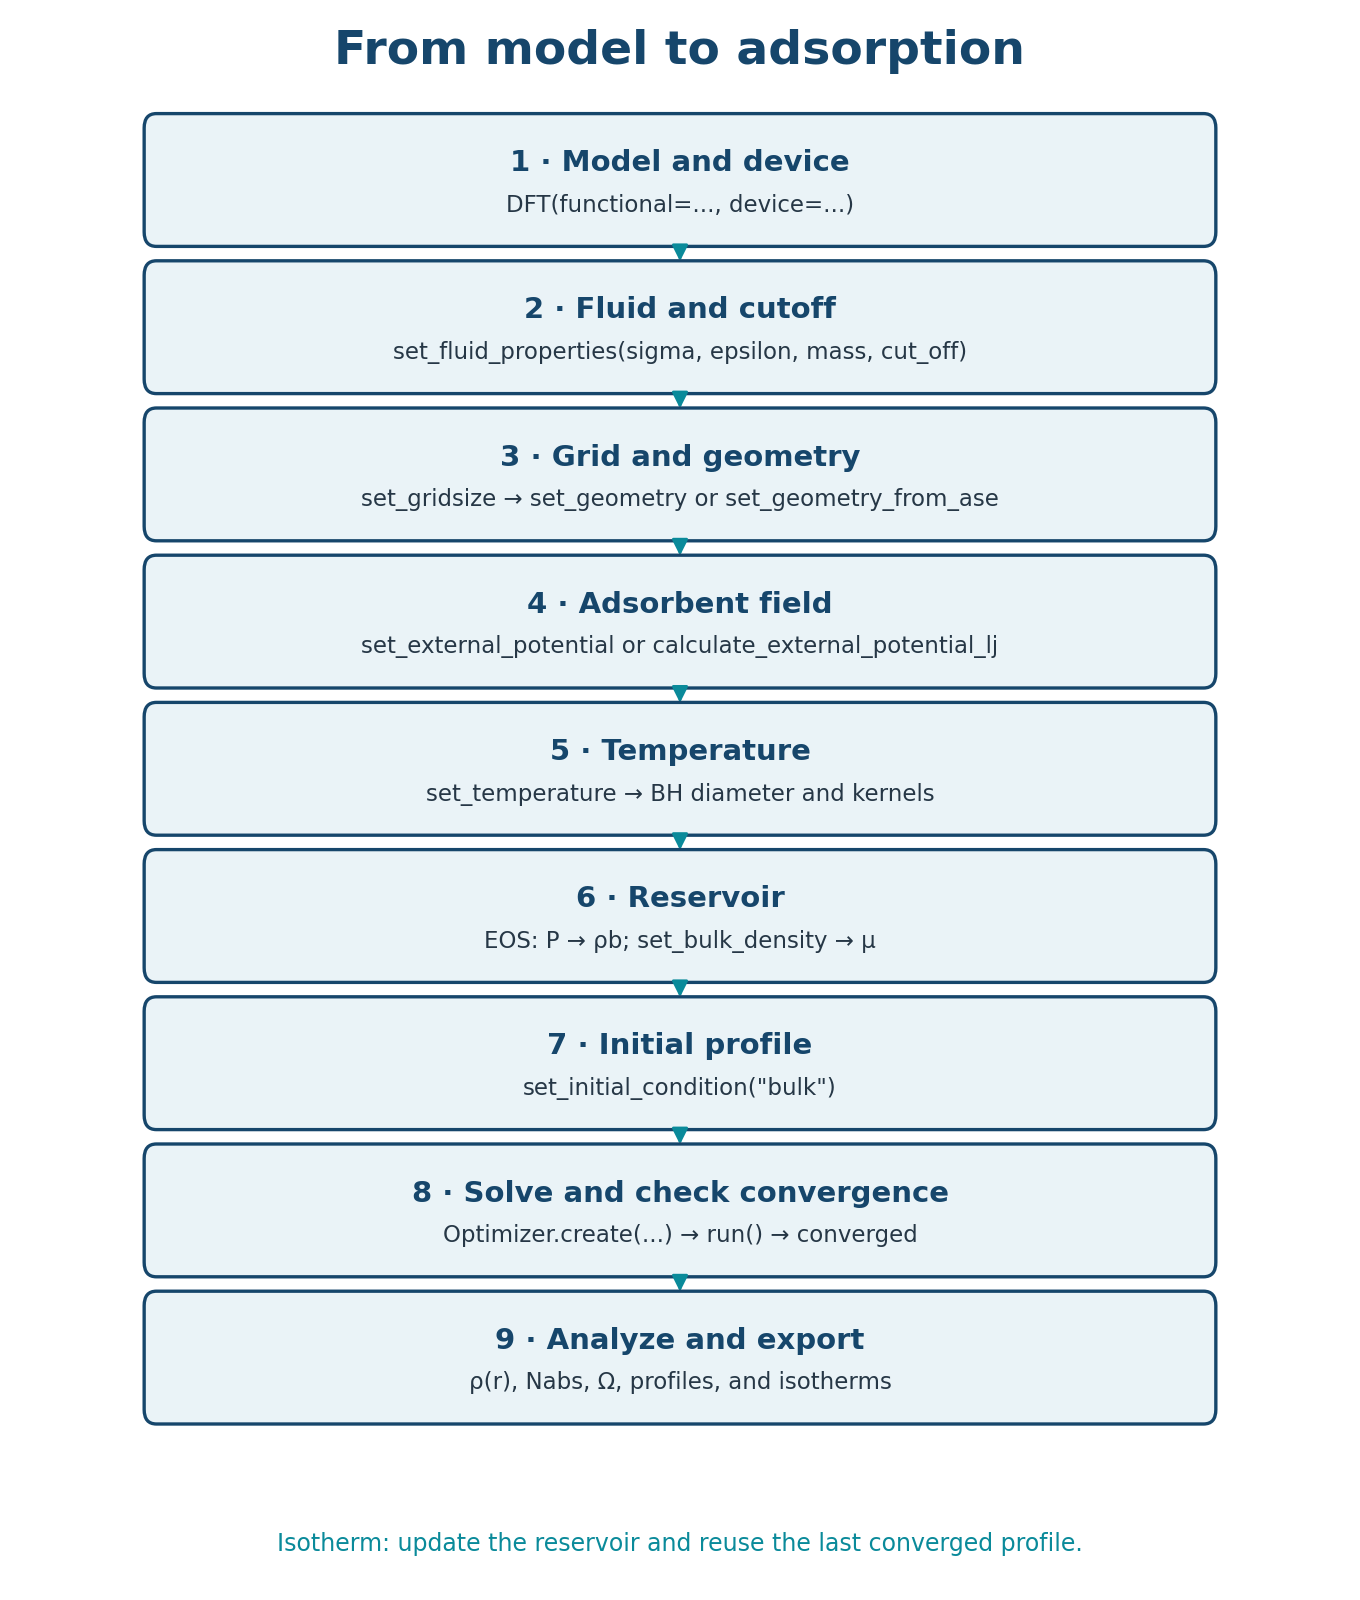

Order matters: `set_temperature()` creates kernels and accessible regions from the field already defined. Updating `rhob` changes the reservoir; updating the initial profile discards the previous guess. Along an isotherm, we retain the converged profile for the next pressure.



### 2.2 Arguments you will actually adjust

| Call | Arguments and effect |
|---|---|
| `DFT(functional, device)` | Repulsive + attractive contributions; `cpu` or `cuda` |
| `set_fluid_properties(sigma, epsilon, mass, cut_off)` | Fluid scales, mass, and kernel range |
| `set_gridsize(gridsize)` | Spacing in each direction |
| `set_geometry(lengths)` | Scalar: effective 1D; tuple of three lengths: 3D |
| `set_geometry_from_ase(atoms)` | Structure and orthogonal cell from ASE |
| `set_external_potential(Vext)` | Array with the same shape as `Ngrid` |
| `set_temperature(kT)` | Temperature in the adopted convention |
| `set_bulk_density(rhob)` | Reservoir number density and chemical potential |
| `set_initial_condition(model="bulk")` | Initial profile; the option is case-sensitive |
| `Optimizer.create(name, system, ...)` | Picard: `alpha`; Anderson: `alpha`, `history_size`, `regularization`; FIRE: `dt`, `dt_max`, `mode` |
| `LJEOS(sigma, epsilon)` | `p(rho,T)`, `mu(rho,T)`, and `VLE()` without creating a DFT object |

The setup methods modify the object. Results are read from `rho`, `Vext`, `Omega`, `Nabs`, and the exported files.

## 3. Units without mystery

The package receives numbers without unit metadata. In dimensional examples, we adopt Å, K, and particles. **Temperature in K is not an energy**: the other energy values are divided by $k_B$, making `beta=1/T` compatible with them.

### 3.1 Inputs

| Variable / argument | Unit | Note |
|---|---|---|
| `sigma`, `gridsize`, `lengths`, CIF positions | Å | ASE uses Å; `gridsize` is a spacing, not a number of points |
| `epsilon` | K | Value of $\epsilon/k_B$; divide an energy in joules by $k_B$ |
| `kT` in `set_temperature` | K | Historical argument name; we supply T in the dimensional convention |
| `Vext` | K | External–fluid energy divided by $k_B$ |
| `rhob` | Particles/Å³ | Number density; not mol/L or kg/m³ |
| `mass` | u | Mass of one molecule; numerically equal to molar mass in g/mol |
| `pbar_values`, `pbar` | bar | Inputs to the package pressure routes |
| `sigma/AA`, `epsilon/kB` in the force field | Å, K | Parameters by solid element; the helper applies Lorentz–Berthelot |
| `cut_off` | Length in the fluid–fluid kernel | The atomistic helper uses another convention in this commit; see the note below |
| Solver `alpha`, `rtol`, `atol` | Dimensionless | The tolerance acts on the residual in $\ln\rho$; FIRE `dt` is not physical time |

### 3.2 Outputs

| Variable / result | Unit | Note |
|---|---|---|
| `rho`, `rhob` | Particles/Å³ | $\rho^*=\rho\sigma^3$ is dimensionless |
| `Vext`, `mu`, `muid`, `muexc` | K | For J per particle, multiply by $k_B$ |
| `c1`, `beta*Vext`, `beta*mu`, `n3` | Dimensionless | `c1` has the opposite sign of the derivative of $\beta F^{exc}$; `n3` is a weighted density |
| `Fid`, `Fhs`, `Flj`, `Omega` | K per numerical cell | Multiply by $k_B$ for J per cell; these are not molar energies |
| `eos.p(rho,T)` | K/Å³ | Multiply by $k_B\,10^{25}$ for bar |
| `Volbox`, `Vol`, `Vpore` | Å³ | Geometric, numerical, and He-accessible volumes, respectively |
| `Nabs` | Particles per numerical cell | In 1D, use $N/A=\int\rho(z)dz$ for comparison per area |
| `helium_fraction` | Dimensionless | `Vpore/Volbox`; depends on the He-probe convention |
| Isotherm file | Indicated in each column | Includes bar, mol/kg, and excess adsorption; read the header before converting |
| Field in `.cube` | Chosen at export | In this notebook: potential $V/T$ and density in particles/Å³; ASE converts coordinates to the format convention |

**Cutoff:** in `aux.lj_potential`, the test is `r > rcut*sigma`, whereas `lj3dFT` receives a length. This must be audited before transferring literature parameters. The MOF case retains the original numerical convention for comparison.

**Reduced units:** with $\sigma=\epsilon=1$, interpret $r,T,\rho$ as $r^*,T^*,\rho^*$. The Å/K labels printed by the package do not change automatically. The `pbar` routes assume the dimensional convention.

The internal chemical potential uses a conventional zero for the ideal contribution. Compare Ω between states that use the same $\mu$ convention. Below, three factors show typical conversions without hiding the calculation in helper functions.

In [ ]:
# Three factors are enough for the conversions used in the course.
kB = 1.380649e-23       # J/K
NA = 6.02214076e23      # 1/mol
amu = 1.66053906660e-27 # kg

K_A3_para_bar = kB * 1e30 / 1e5
rho_A3_para_mol_m3 = 1e30 / NA
K_para_kJ_mol = kB * NA / 1000

tabela_unidades = pd.DataFrame({
    "Quantity": ["Density", "Pressure", "Energy"],
    "Internal value": [1.0e-3, 0.25, 300.0],
    "Internal unit": ["molecules/Å³", "K/Å³", "K"],
    "Converted value": [
        1.0e-3 * rho_A3_para_mol_m3,
        0.25 * K_A3_para_bar,
        300.0 * K_para_kJ_mol,
    ],
    "Converted unit": ["mol/m³", "bar", "kJ/mol"],
})
display(tabela_unidades.style.format({"Internal value": "{:.4g}", "Converted value": "{:.5g}"}))


,Grandeza,Valor interno,Unidade interna,Valor convertido,Unidade convertida
0,Density,0.001,molecules/Å³,1660.5,mol/m³
1,Pressure,0.25,K/Å³,34.516,bar
2,Energia,300,K,2.4943,kJ/mol


## 4. The EOS before cDFT

`LJEOS` can be used without creating a DFT object. We will first examine $p(\rho)$ and $\mu(\rho)$ for effective TraPPE CH₄ and then vapor–liquid equilibrium.

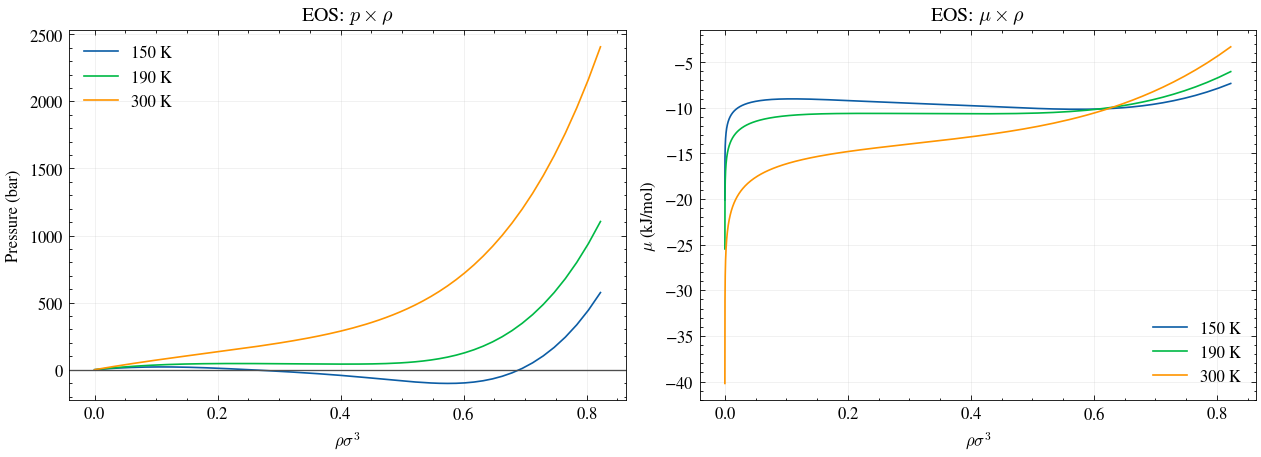

In [ ]:
sigma = 3.73    # Å, effective TraPPE-UA CH4
epsilon = 148.0 # K
mass = 16.043   # u

eos = LJEOS(sigma=sigma, epsilon=epsilon)
rho = torch.logspace(-7, -1.80, 500, dtype=torch.float64) # molecules/Å³
temperaturas = [150.0, 190.0, 300.0]                     # K

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
for temp in temperaturas:
    p = eos.p(rho, temp).numpy() * K_A3_para_bar
    mu = eos.mu(rho, temp).numpy() * K_para_kJ_mol
    ax[0].plot(rho.numpy() * sigma**3, p, label=f"{temp:.0f} K")
    ax[1].plot(rho.numpy() * sigma**3, mu, label=f"{temp:.0f} K")

ax[0].axhline(0, color="0.3", lw=0.8)
ax[0].set(xlabel=r"$\rho\sigma^3$", ylabel="Pressure (bar)", title=r"EOS: $p\times\rho$")
ax[1].set(xlabel=r"$\rho\sigma^3$", ylabel=r"$\mu$ (kJ/mol)", title=r"EOS: $\mu\times\rho$")
for eixo in ax:
    eixo.legend(frameon=False)
plt.show()


### 4.1 Vapor–liquid equilibrium

`VLE()` finds the critical point from $\partial p/\partial\rho=\partial^2p/\partial\rho^2=0$ and follows coexistence by imposing $p_v=p_l$ and $\mu_v=\mu_l$. The three projections below show the same thermodynamic information.

In [ ]:
dados = Path("dados_curso")
dados.mkdir(exist_ok=True)

arquivo = dados / "methane-saturation.dat"
if not arquivo.exists():
    urlretrieve(f"{RAW}/examples/data/experimental/methane-saturation.dat", arquivo)
exp = pd.read_csv(arquivo, sep="\t")

rho_c, T_c, rho_sat, T_sat, p_sat = eos.VLE(kTmin=0.65)
n = len(rho_sat) // 2

# Conversions to units familiar to the adsorption community.
rho_sat = rho_sat * 1e30 * mass * amu
p_sat = p_sat * K_A3_para_bar
rho_c = rho_c * 1e30 * mass * amu

rho_v, rho_l = rho_sat[:n], rho_sat[n:]
T_v, T_l = T_sat[:n], T_sat[n:]
p_v, p_l = p_sat[:n], p_sat[n:]


We will bring together the three coexistence diagrams: temperature–density, saturation pressure–temperature, and saturation pressure–density. Matching colors identify the same branch in the curves and data.

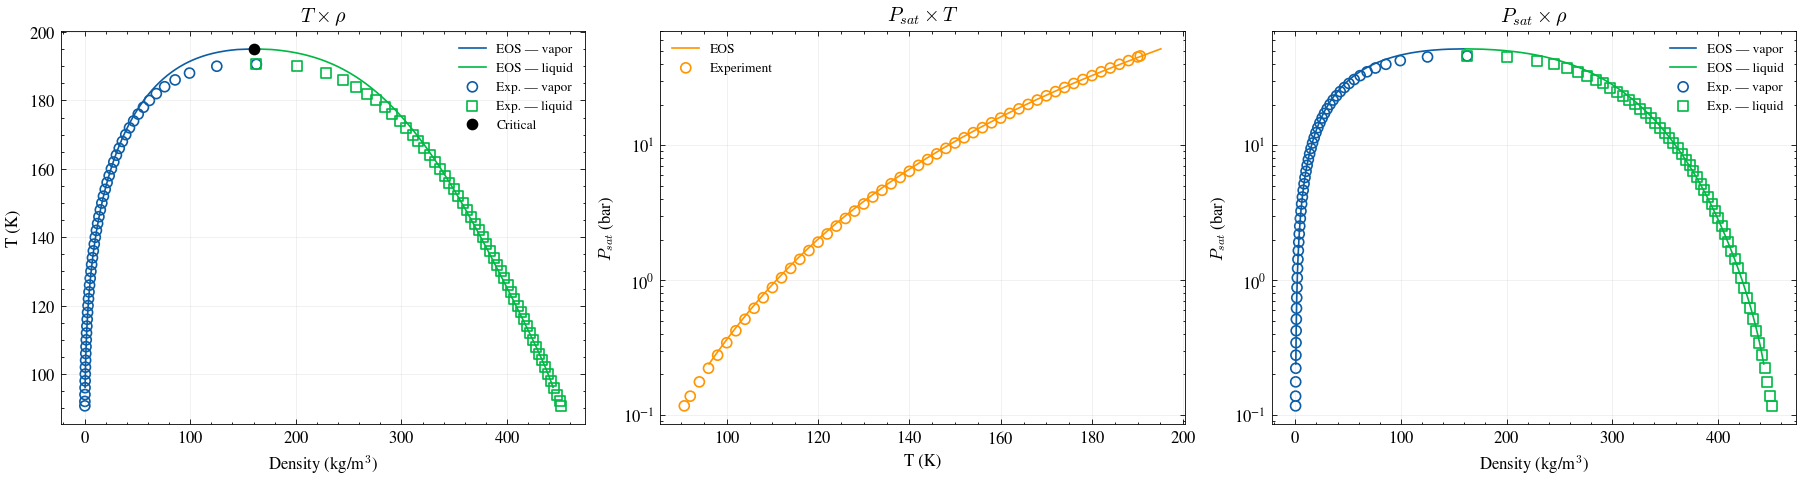

In [ ]:
vapor, liquido, pressao = "C0", "C1", "C2"
p_exp = 10 * exp["Pressure (MPa)"]

fig, ax = plt.subplots(1, 3, figsize=(15.0, 4.0), constrained_layout=True)

# T x rho
ax[0].plot(rho_v, T_v, color=vapor, label="EOS — vapor")
ax[0].plot(rho_l, T_l, color=liquido, label="EOS — liquid")
ax[0].scatter(exp["Vapor Density (kg/m3)"], exp["Temperature (K)"],
              facecolors="none", edgecolors=vapor, label="Exp. — vapor")
ax[0].scatter(exp["Liquid Density (kg/m3)"], exp["Temperature (K)"],
              marker="s", facecolors="none", edgecolors=liquido, label="Exp. — liquid")
ax[0].plot(rho_c, T_c, "ko", label="Critical")

# Psat x T
ax[1].plot(T_v, p_v, color=pressao, label="EOS")
ax[1].scatter(exp["Temperature (K)"], p_exp,
              facecolors="none", edgecolors=pressao, label="Experiment")

# Psat x rho
ax[2].plot(rho_v, p_v, color=vapor, label="EOS — vapor")
ax[2].plot(rho_l, p_l, color=liquido, label="EOS — liquid")
ax[2].scatter(exp["Vapor Density (kg/m3)"], p_exp,
              facecolors="none", edgecolors=vapor, label="Exp. — vapor")
ax[2].scatter(exp["Liquid Density (kg/m3)"], p_exp,
              marker="s", facecolors="none", edgecolors=liquido, label="Exp. — liquid")

titulos = [r"$T\times\rho$", r"$P_{sat}\times T$", r"$P_{sat}\times\rho$"]
for eixo, titulo in zip(ax, titulos):
    eixo.set_title(titulo)
    eixo.legend(frameon=False, fontsize=8)
ax[0].set(xlabel=r"Density (kg/m$^3$)", ylabel="T (K)")
ax[1].set(xlabel="T (K)", ylabel=r"$P_{sat}$ (bar)", yscale="log")
ax[2].set(xlabel=r"Density (kg/m$^3$)", ylabel=r"$P_{sat}$ (bar)", yscale="log")
plt.savefig("v6_diagrama_fases_CH4.png", dpi=220, bbox_inches="tight")
plt.show()


### Exercise 1: Determination and analysis of vapor–liquid equilibrium ($\text{N}_2$ and $\text{Ar}$)

#### Objective
Calculate and plot the vapor–liquid equilibrium (VLE) envelope for molecular nitrogen ($\text{N}_2$) and argon ($\text{Ar}$), evaluating the thermodynamic behavior of the pure fluids through the following phase diagrams:

1. **Phase-coexistence diagram ($\rho \times T$):** Density curves for the liquid ($\rho_{\mathrm{liq}}$) and vapor ($\rho_{\mathrm{vap}}$) phases as functions of temperature, highlighting the two-phase region and approach to the critical point.
2. **Saturation-pressure curve ($T \times P_{\mathrm{sat}}$ or $\ln P_{\mathrm{sat}} \times 1/T$):** Evolution of vapor pressure with temperature along the equilibrium line.
3. **Isotherms and coexistence envelopes ($\rho \times P_{\mathrm{sat}}$):** Density behavior as a function of equilibrium pressure for different isothermal conditions.

---

#### Parameters compatible with the one-site EOS

PyDFTlj does not directly implement multisite, charged TraPPE N₂. Its values $\sigma=3.310$ Å and $\epsilon/k_B=36$ K are **per N site**: inserting them into `LJEOS` does not reproduce the VLE of molecular N₂.

For this exercise with the course library, use:

| Fluid / model | Representation | σ [Å] | ε/kB [K] | Mass [u] |
|---|---|---:|---:|---:|
| LJ Ar | One atom | 3.405 | 119.8 | 39.948 |
| Effective N₂ | One site per molecule, without quadrupole | 3.615 | 101.5 | 28.0134 |

Effective N₂ uses the LJ–MC parameters of Ravikovitch et al. used in section 9. It is **not the molecular TraPPE force field for N₂**. Discuss this limitation when interpreting the envelopes. The Ar parameters form a conventional LJ model; the TraPPE n-alkane reference should not be used as a specific source for Ar.

---

#### References

* **$\text{N}_2$ (TraPPE):** Potoff, J. J.; Siepmann, J. I. *Vapor–Liquid Equilibria of Mixtures Containing Alkanes, Carbon Dioxide, and Nitrogen.* **AIChE Journal**, v. 47, n. 7, p. 1676–1682, 2001. [DOI: 10.1002/aic.690470719](https://doi.org/10.1002/aic.690470719)
* **LJ Ar:** Rahman, A. *Correlations in the Motion of Atoms in Liquid Argon*. Physical Review 136, A405 (1964). [DOI](https://doi.org/10.1103/PhysRev.136.A405).
* **Effective N₂:** Ravikovitch et al., Langmuir 16, 2311–2320 (2000), LJ–MC parameters from Table 1. [DOI](https://doi.org/10.1021/la991011c).

In [1]:
# Exercise 1 resolution





### 4.2 From the EOS to cDFT: the uniform limit

For a uniform fluid, $\rho(\mathbf r)=\rho_b$ and

$$F[\rho_b]=Vf(\rho_b),\qquad
\frac{\delta F}{\delta\rho(\mathbf r)}=\frac{\partial f}{\partial\rho}\bigg|_{\rho_b}=\mu_{bulk}.$$

Without an external field,

$$\frac{\Omega}{V}=f(\rho_b)-\mu\rho_b,$$

and the equilibrium condition is precisely $\partial f/\partial\rho=\mu$. cDFT replaces the scalar $\rho_b$ with the field $\rho(\mathbf r)$, but it must recover this EOS when the field becomes uniform again.

## 5. Essential equations and models

### 5.1 Grand potential

| Term | Mathematical expression | Physical role | In PyDFTlj |
|---|---|---|---|
| Ideal | $$F^{id}[\rho]=k_BT\int\rho(\mathbf r)\{\ln[\rho(\mathbf r)\Lambda^3]-1\}\,d\mathbf r$$ | Translational entropy | `Fid` |
| Excess | $$F^{exc}[\rho]=F^{hs}[\rho]+F^{att}[\rho]$$ | Excluded volume and attraction | `Fhs, Flj` |
| Solid–fluid | $$\int V_{ext}(\mathbf r)\rho(\mathbf r)\,d\mathbf r$$ | Adsorbent geometry and chemistry | `Vext` |
| Reservoir | $$-\mu\int\rho(\mathbf r)\,d\mathbf r$$ | Particle exchange with the bulk | `mu, rhob` |

$$\Omega[\rho]=F^{id}[\rho]+F^{exc}[\rho]+\int[V_{ext}(\mathbf r)-\mu]\rho(\mathbf r)\,d\mathbf r.$$

### 5.2 Equilibrium: minimize Ω

At fixed temperature, chemical potential, and external field, the equilibrium profile minimizes the functional:

$$\rho_{eq}=\underset{\rho\geq0}{\operatorname{arg\,min}}\;\Omega[\rho],\qquad
\left.\frac{\delta\Omega}{\delta\rho(\mathbf r)}\right|_{\rho_{eq}}=0.$$

Stationarity gives the **Euler–Lagrange equation** in the accessible regions:

$$k_BT\ln[\rho(\mathbf r)\Lambda^3]+\frac{\delta F^{exc}}{\delta\rho(\mathbf r)}+V_{ext}(\mathbf r)-\mu=0.$$

With $c^{(1)}(\mathbf r)=-\beta\,\delta F^{exc}/\delta\rho(\mathbf r)$,

$$\rho(\mathbf r)=\Lambda^{-3}\exp[\beta\mu-\beta V_{ext}(\mathbf r)+c^{(1)}(\mathbf r)].$$

Eliminating the ideal contribution through the bulk state:

$$\rho(\mathbf r)=\rho_b\exp[-\beta V_{ext}(\mathbf r)+c^{(1)}(\mathbf r)+\beta\mu^{exc}(\rho_b)].$$

The solver seeks a zero residual in $\ln\rho$. **A small residual guarantees stationarity, not the global minimum.** In the hysteresis section we will compare Ω for two converged profiles in the same reservoir.

The next cell shows how `compute_force` writes this residual in the code.

In [ ]:
# The Euler–Lagrange equation is implemented in only a few lines.
print(inspect.getsource(DFT.compute_force))


    def compute_force(self):
        F = -(self.lnrho - self.c1 - self.beta * self.mu + self.beta * self.Vext)
        F[~self.allowed] = 0.0  # Set force to zero in forbidden regions
        return F



### 5.3 Available functionals

A single string combines the two contributions: `"aWBI+MMFA"`. Without an attractive suffix, for example `"WBI"`, the system consists of hard spheres.

| Contribution | Option | Idea | Reference / implementation |
|---|---|---|---|
| **Repulsive · FMT** | `RF` | Original Rosenfeld; geometric weight functions, Percus–Yevick bulk limit | [Rosenfeld, 1989](https://doi.org/10.1103/PhysRevLett.63.980) |
| **Repulsive · FMT** | `WBI` | White Bear I; improves bulk hard-sphere thermodynamics, associated with Carnahan–Starling | [Roth et al., 2002](https://doi.org/10.1088/0953-8984/14/46/313); [Yu & Wu, 2002](https://doi.org/10.1063/1.1520530) |
| **Repulsive · FMT** | `WBII` | White Bear II; revised density functions for greater thermodynamic consistency | [Hansen-Goos & Roth, 2006](https://doi.org/10.1088/0953-8984/18/37/002) |
| **Repulsive · FMT** | `aRF`, `aWBI`, `aWBII` | Asymmetric variants: vector-field dependence through $\xi$; retain the homogeneous limit of their respective bases | [`startswith('a')` branch in `dft.py`](https://github.com/elvissoares/PyDFTlj/blob/16e7d4349e22d3ead8774a332011b4c3d21806cd/pydftlj/dft.py); FMT family above |
| **Attractive · LJ** | `MFA` | Quadratic mean-field convolution; kernel with WCA separation; its own mean-field bulk EOS | [Weeks–Chandler–Andersen, 1971](https://doi.org/10.1063/1.1674820); explicit call below |
| **Attractive · LJ** | `WDA` | Attractive excess evaluated at a weighted density, obtained from the LJ EOS minus the HS reference | [Shen, Ji & Lu, 2013](https://doi.org/10.1063/1.4808160) |
| **Attractive · LJ** | `MMFA` | Mean field with a BH kernel and weighted-density correction; recovers the adopted LJ EOS | [Soares, Barreto & Tavares, 2021](https://doi.org/10.1016/j.fluid.2021.113095) |

WDA and MMFA recover the LJ/MBWR EOS used by the package; MFA does not have the same bulk EOS. See [Johnson, Zollweg & Gubbins, 1993](https://doi.org/10.1080/00268979300100411).

### 5.4 EOS–functional consistency in one figure

In the uniform field, consistency requires

$$\beta\mu^{exc}(\rho_b)=-\left.c^{(1)}(\mathbf r)\right|_{\rho=\rho_b}.$$

We will compare `s.beta*s.muexc` with `-s.c1.mean()`: both are dimensionless. The minus sign is essential. The diagonal represents equality; WDA and MMFA nearly coincide because they recover the same EOS. We use different symbols and annotations without shifting the data.

The table headers are written out so that they also work where pandas HTML does not render LaTeX. The axes use mathematical notation.

Grid defined!
Lgrid = (np.float32(6.0), np.float32(0.5), np.float32(0.5))  A
X-axis = [ 0.0 , 6.0 ] A
Y-axis = [ 0.0 , 0.5 ] A
Z-axis = [ 0.0 , 0.5 ] A
Number of gridpoints = (12, 1, 1)
delta =  [0.5 0.5 0.5]  A
Vol = 1.5  A³
Grid defined!
Lgrid = (np.float32(6.0), np.float32(0.5), np.float32(0.5))  A
X-axis = [ 0.0 , 6.0 ] A
Y-axis = [ 0.0 , 0.5 ] A
Z-axis = [ 0.0 , 0.5 ] A
Number of gridpoints = (12, 1, 1)
delta =  [0.5 0.5 0.5]  A
Vol = 1.5  A³
Grid defined!
Lgrid = (np.float32(6.0), np.float32(0.5), np.float32(0.5))  A
X-axis = [ 0.0 , 6.0 ] A
Y-axis = [ 0.0 , 0.5 ] A
Z-axis = [ 0.0 , 0.5 ] A
Number of gridpoints = (12, 1, 1)
delta =  [0.5 0.5 0.5]  A
Vol = 1.5  A³


,Functional,Excess chemical potential / kBT,Minus uniform direct correlation,Difference
0,WBI+MFA,-1.414004,-1.414004,-0.000000
1,WBI+WDA,-1.049361,-1.049382,-0.000021
2,WBI+MMFA,-1.049361,-1.049382,-0.000021


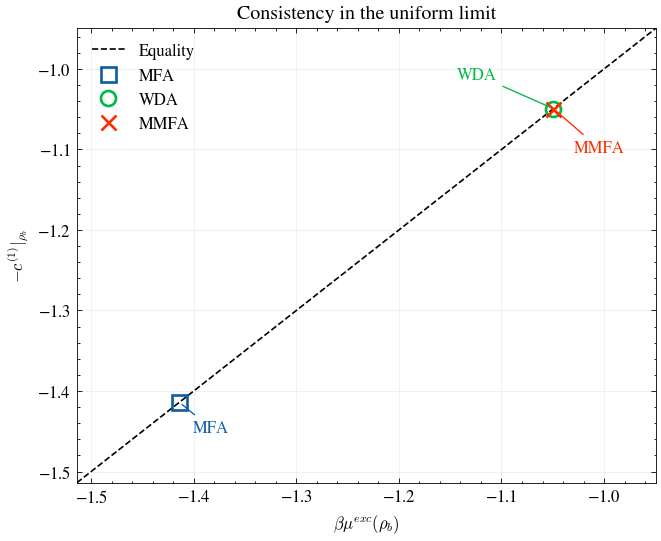

In [ ]:
comparacao = []

for modelo in ["WBI+MFA", "WBI+WDA", "WBI+MMFA"]:
    s = DFT(functional=modelo, device=DEVICE_1D)
    s.set_fluid_properties(sigma=1.0, epsilon=1.0, mass=1.0, cut_off=3.5)
    s.set_gridsize(gridsize=0.5)
    s.set_geometry(lengths=6.0)
    s._from_ase = False  # manually defined geometry in v1.0.3
    s.set_external_potential(np.zeros(s.Ngrid, dtype=np.float32))
    s.set_temperature(kT=1.35)
    s.set_bulk_density(rhob=0.20)
    s.set_initial_condition(model="bulk")

    mu_eos = s.beta * float(s.muexc)
    mu_func = -float(s.c1.mean())
    comparacao.append([modelo, mu_eos, mu_func, mu_func - mu_eos])

consistencia = pd.DataFrame(
    comparacao,
    columns=["Functional", "Excess chemical potential / kBT", "Minus uniform direct correlation", "Difference"],
)
display(consistencia.style.format(precision=6))


fig, ax = plt.subplots(figsize=(5.5, 4.5), constrained_layout=True)
lim = [consistencia[["Excess chemical potential / kBT", "Minus uniform direct correlation"]].min().min() - 0.1,
       consistencia[["Excess chemical potential / kBT", "Minus uniform direct correlation"]].max().max() + 0.1]
ax.plot(lim, lim, "k--", lw=1, label="Equality")

# WDA and MMFA nearly coincide: an open circle and a cross reveal both points.
estilos = [("s", "C0", (8, -18)), ("o", "C1", (-58, 18)), ("x", "C3", (12, -26))]
for (_, linha), (marcador, cor, offset) in zip(consistencia.iterrows(), estilos):
    nome = linha["Functional"].split("+")[1]
    ax.plot(linha["Excess chemical potential / kBT"], linha["Minus uniform direct correlation"],
            marker=marcador, color=cor, ms=9, mfc="none", mew=1.6, ls="none", label=nome)
    ax.annotate(nome, (linha["Excess chemical potential / kBT"], linha["Minus uniform direct correlation"]),
                xytext=offset, textcoords="offset points", color=cor,
                arrowprops={"arrowstyle": "-", "color": cor, "lw": 0.8})
ax.set(xlabel=r"$\beta\mu^{exc}(\rho_b)$", ylabel=r"$-c^{(1)}|_{\rho_b}$",
       xlim=lim, ylim=lim, title="Consistency in the uniform limit")
ax.legend(frameon=False, loc="upper left")
plt.show()


# Part B — 1D adsorption in carbon

## 6. External potential: parameters before the solver

For a planar wall,

$$V_S(z)=\epsilon_w\left[\frac25\left(\frac{\sigma_w}{z}\right)^{10}
-\left(\frac{\sigma_w}{z}\right)^4
-\frac{\sigma_w^4}{3\Delta(z+0.61\Delta)^3}\right].$$

$\epsilon_w$ mainly controls the depth; $\sigma_w$ shifts the repulsive region and the minimum. For a slit, we add $V_S(z)+V_S(H-z)$.

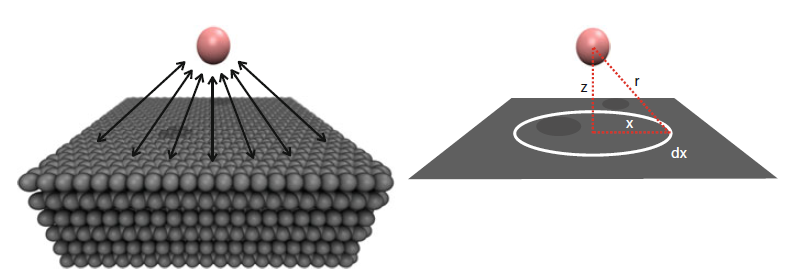

On the left, the molecule interacts with many atoms distributed in layers. On the right, we replace the sum within a layer by an integration over rings, with $r^2=z^2+x^2$ and area element $2\pi x\,dx$. Integrating the LJ 12–6 potential over the plane produces the **10–4** terms; the contribution from deeper layers is approximated by the **3** term. This lateral averaging removes atomistic corrugation and produces $V_S(z)$.

For carbon, the prefactor is $\epsilon_w=2\pi\rho_s\Delta\epsilon_{sf}\sigma_{sf}^2$. The image was provided by the instructor; the derivation is from [Steele, 1973](https://doi.org/10.1016/0039-6028(73)90264-1). We now vary energy and size to recognize their effects on the potential.


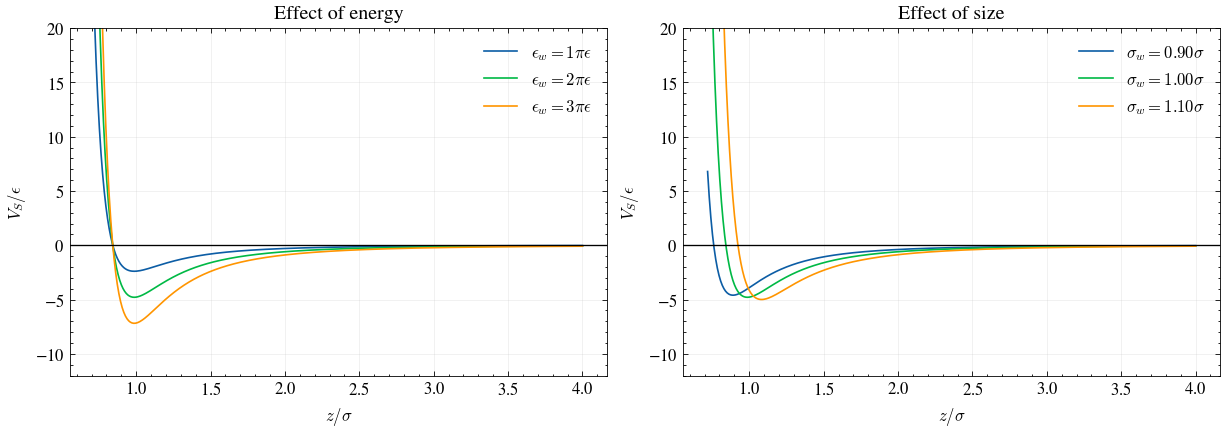

In [ ]:
def steele(z, epsilon_w=2*np.pi, sigma_w=1.0, delta=1/np.sqrt(2)):
    return epsilon_w * (
        0.4 * (sigma_w/z)**10 - (sigma_w/z)**4
        - sigma_w**4 / (3*delta*(z + 0.61*delta)**3)
    )

z_teste = np.linspace(0.72, 4.0, 600)
fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.6), constrained_layout=True)

for fator in [1.0, 2.0, 3.0]:
    ax[0].plot(z_teste, steele(z_teste, epsilon_w=fator*np.pi), label=fr"$\epsilon_w={fator:g}\pi\epsilon$")
for sigma_w in [0.90, 1.00, 1.10]:
    ax[1].plot(z_teste, steele(z_teste, sigma_w=sigma_w), label=fr"$\sigma_w={sigma_w:.2f}\sigma$")

for eixo in ax:
    eixo.axhline(0, color="k", lw=0.8)
    eixo.set(xlabel=r"$z/\sigma$", ylabel=r"$V_S/\epsilon$", ylim=(-12, 20))
    eixo.legend(frameon=False)
ax[0].set_title("Effect of energy")
ax[1].set_title("Effect of size")
plt.show()


We now build a slit isolated from its periodic images by forbidden regions. The function will be reused when changing the functional and width.

In [ ]:
def criar_fenda(H, modelo="WBI+MMFA", dz=0.025):
    """Slit 0<z<H, isolated from periodic images by a buffer."""
    cutoff = buffer = 5.0
    s = DFT(functional=modelo, device=DEVICE_1D)
    s.set_fluid_properties(sigma=1.0, epsilon=1.0, mass=1.0, cut_off=cutoff)
    s.set_gridsize(gridsize=dz)
    s.set_geometry(lengths=H + 2*buffer)
    s._from_ase = False

    z = np.squeeze(s.X) - buffer
    dentro = (z > dz/2) & (z < H - dz/2)
    V = np.full_like(z, np.inf, dtype=np.float32)
    V[dentro] = steele(z[dentro]) + steele(H - z[dentro])

    s.set_external_potential(V.reshape(s.Ngrid))
    s.set_temperature(kT=1.2)
    s.set_bulk_density(rhob=0.5925)
    s.set_initial_condition(model="bulk")
    return s, z


Grid defined!
Lgrid = (np.float32(13.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 13.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (520, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.008125001  A³
Grid defined!
Lgrid = (np.float32(17.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 17.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (680, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.010625  A³
Grid defined!
Lgrid = (np.float32(30.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 30.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (1200, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.01875  A³


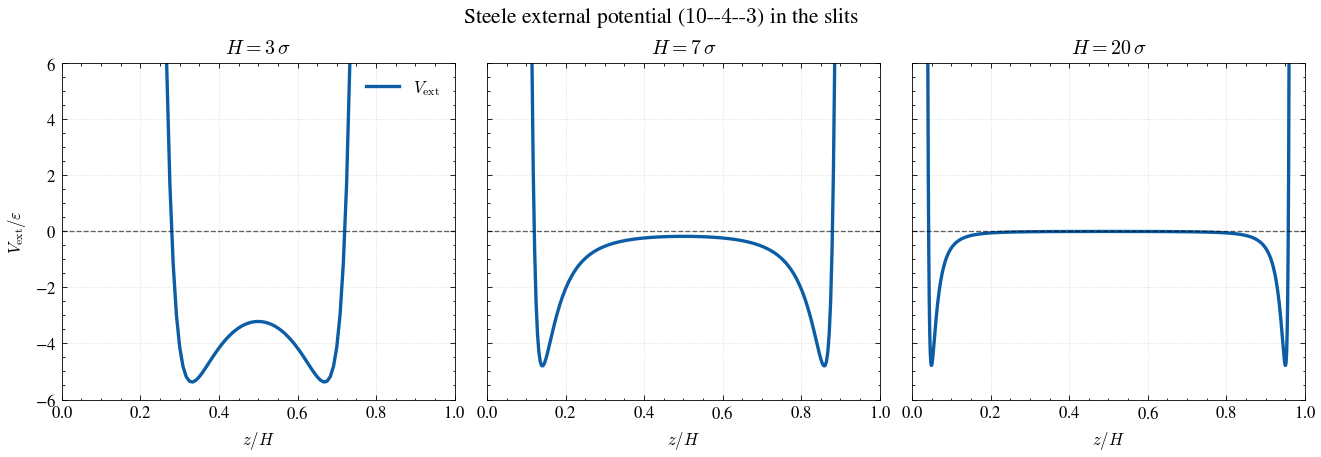

In [ ]:
Hs = [3.0, 7, 20]

fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.8), constrained_layout=True, sharey=True)

for ax, H in zip(axes, Hs):
    s, z = criar_fenda(H)
    V = np.squeeze(s.Vext)

    # Select only the interior of the pore
    dentro = (z >= 0) & (z <= H)

    ax.plot(z[dentro] / H, V[dentro], color="C0", lw=2, label=r"$V_{\mathrm{ext}}$")

    ax.axhline(0, color="k", ls="--", lw=0.8, alpha=0.6)
    ax.set(
        title=fr"$H = {H:g}\,\sigma$",
        xlabel=r"$z/H$",
        xlim=(0, 1),
        ylim=(-6.0, 6.0)
    )
    ax.grid(True, ls=":", alpha=0.5)

axes[0].set_ylabel(r"$V_{\mathrm{ext}} / \varepsilon$")
axes[0].legend(frameon=False)
fig.suptitle(r"Steele external potential ($10\text{--}4\text{--}3$) in the slits", fontsize=13)

plt.savefig("v6_potencial_por_largura.png", dpi=220, bbox_inches="tight")
plt.show()

## 7. MFA, WDA, and MMFA versus GCMC — a single plot

We will change only `functional`: the geometry, reservoir, and potential remain the same.

The slit has intense density peaks. Starting Anderson directly from the bulk can produce an excessively large step. We therefore use two explicit stages: **FIRE with a small step brings the profile closer; Anderson completes the solution**. The final profile must satisfy `atol=1e-8`, `rtol=1e-4` for every model—we do not relax the tolerance to include MFA.

FIRE in the first stage is a preparation and need not have converged already. The table records iterations from both stages and the final Anderson error.

**About the origin of the points:** the headers of the repository files cite [Snook & van Megen, *Solvation forces in simple dense fluids. I*, 1980](https://doi.org/10.1063/1.439489), which uses Monte Carlo in the grand canonical ensemble (**GCMC**). The `GEMC` suffix was retained in the filenames for compatibility; it does not mean Gibbs Ensemble Monte Carlo in this dataset. The original example also labels them simply as “MC.”

In [ ]:
modelos = ["WBI+MFA", "WBI+WDA", "WBI+MMFA"]
solucoes, linhas = {}, []

for modelo in modelos:
    s, z = criar_fenda(H=7.5, modelo=modelo)
    inicio = time.perf_counter()

    # 1. Conservative approach: avoids the initial jump to excessive densities.
    fire = Optimizer.create(
        "fire", s, mode="fire", dt=0.002, dt_max=0.02,
        atol=1e-8, rtol=1e-4, max_iter=3000,
    )
    fire.run()

    # 2. Final correction without resetting the density prepared by FIRE.
    opt = Optimizer.create(
        "anderson", s, alpha=0.10, regularization=1e-6,
        atol=1e-8, rtol=1e-4, max_iter=15000,
    )
    erro, n_iter = opt.run()
    linhas.append([modelo, fire.Niter, n_iter, time.perf_counter()-inicio, erro, opt.converged])
    if not opt.converged:
        raise RuntimeError(f"{modelo} did not converge: Error={erro:.3e}; {opt.stop_reason}")
    solucoes[modelo] = (s, z)

convergencia_1d = pd.DataFrame(
    linhas, columns=["Functional", "FIRE iterations", "Anderson iterations", "Time (s)", "Error", "Converged"]
)
display(convergencia_1d.style.format({"Time (s)": "{:.3f}", "Error": "{:.2e}"}))


Grid defined!
Lgrid = (np.float32(17.5), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 17.5 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (700, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.0109375  A³
Grid defined!
Lgrid = (np.float32(17.5), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 17.5 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (700, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.0109375  A³
Grid defined!
Lgrid = (np.float32(17.5), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 17.5 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (700, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.0109375  A³


,Functional,FIRE iterations,Anderson iterations,Time (s),Error,Converged
0,WBI+MFA,3000,5,9.325,5.50e-01,True
1,WBI+WDA,937,3,6.080,9.37e-01,True
2,WBI+MMFA,1967,80,13.618,9.02e-01,True


We load the GCMC points and draw the three converged profiles in a single plot. The historical file suffix remains unchanged.

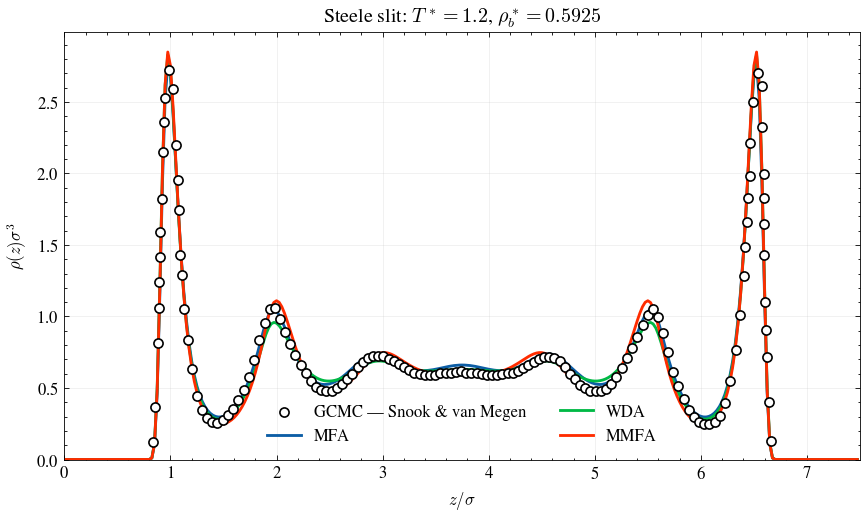

In [ ]:
arquivo_mc = dados / "lj-slitpore-steele-H7.5-GEMC.dat"
if not arquivo_mc.exists():
    urlretrieve(
        f"{RAW}/examples/data/MC/lj-slitpore-steele-T1.2-rhob0.5925-H7.5-GEMC.dat",
        arquivo_mc,
    )
mc = np.loadtxt(arquivo_mc)

fig, ax = plt.subplots(figsize=(7.2, 4.3), constrained_layout=True)
ax.scatter(mc[:, 0], mc[:, 1], s=30, facecolors="white", edgecolors="k", label="GCMC — Snook & van Megen", zorder=4)

cores = {"WBI+MFA": "C0", "WBI+WDA": "C1", "WBI+MMFA": "C3"}
for modelo, (s, z) in solucoes.items():
    dentro = (z >= 0) & (z <= 7.5)
    rho_z = np.squeeze(s.rho.detach().cpu().numpy())
    ax.plot(z[dentro], rho_z[dentro], color=cores[modelo], lw=1.7,
            label=modelo.split("+")[1])

ax.set(xlabel=r"$z/\sigma$", ylabel=r"$\rho(z)\sigma^3$",
       xlim=(0, 7.5), ylim=(0, None), title=r"Steele slit: $T^*=1.2$, $\rho_b^*=0.5925$")
ax.legend(frameon=False, ncol=2)
plt.savefig("v6_Steele_modelos_GCMC.png", dpi=220, bbox_inches="tight")
plt.show()


## 8. Is the pore center bulk-like?

Not necessarily. The walls and correlations may span the entire pore. To make the trend readable, we use seven widths between $3\sigma$ and $12\sigma$ and show four representative profiles.

The $H=1.8\sigma$ and $2.0\sigma$ cases are left outside the main pathway: in this version, the combination of extreme confinement, singular FMT near $n_3=1$, and `float32` precision may require continuation and safeguards that would distract from the class focus. This is an explicit numerical limitation, not a physical result.

In [ ]:
larguras = [3.0, 4.0, 5.0, 6.0, 7.5, 9.0, 12.0]
perfis, resumo = {}, []

for H in larguras:
    s, z = criar_fenda(H, modelo="WBI+MMFA")
    # The same two-stage procedure used in the previous study.
    fire = Optimizer.create("fire", s, mode="fire", dt=0.002, dt_max=0.02,
                            atol=1e-8, rtol=1e-4, max_iter=3000)
    fire.run()
    opt = Optimizer.create("anderson", s, alpha=0.10, regularization=1e-6,
                           atol=1e-8, rtol=1e-4, max_iter=15000)
    erro, n_iter = opt.run()
    if not opt.converged:
        raise RuntimeError(f"H={H:g}: Error={erro:.3e}; {opt.stop_reason}")

    rho_z = np.squeeze(s.rho.detach().cpu().numpy())
    perfis[H] = (z, rho_z)
    rho_centro = float(np.interp(H/2, z, rho_z))
    resumo.append([H, rho_centro, rho_centro/float(s.rhob), fire.Niter+n_iter])

centro = pd.DataFrame(resumo, columns=["H/sigma", "Central density", "Center/bulk ratio", "Iterations"])
display(centro.style.format({"Central density": "{:.5f}", "Center/bulk ratio": "{:.3f}"}))


Grid defined!
Lgrid = (np.float32(13.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 13.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (520, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.008125001  A³
Grid defined!
Lgrid = (np.float32(14.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 14.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (560, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.00875  A³
Grid defined!
Lgrid = (np.float32(15.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 15.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (600, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.009375  A³
Grid defined!
Lgrid = (np.float32(16.0), np.float32(0.025), np.float32(0.025))  A
X-axis = [ 0.0 , 16.0 ] A
Y-axis = [ 0.0 , 0.025 ] A
Z-axis = [ 0.0 , 0.025 ] A
Number of gridpoints = (640, 1, 1)
delta =  [0.025 0.025 0.025]  A
Vol = 0.010000001  A³
Gri

,H/sigma,Central density,Center/bulk ratio,Iterations
0,3.000000,0.08985,0.152,327
1,4.000000,1.78580,3.014,349
2,5.000000,0.32235,0.544,417
3,6.000000,0.96947,1.636,666
4,7.500000,0.59922,1.011,2042
5,9.000000,0.56862,0.960,3086
6,12.000000,0.61366,1.036,380


We compare four profiles in the z/H coordinate. We add GCMC at H/σ = 3, 4, and 7.5; there is no equivalent file for H/σ = 12 in the dataset used.

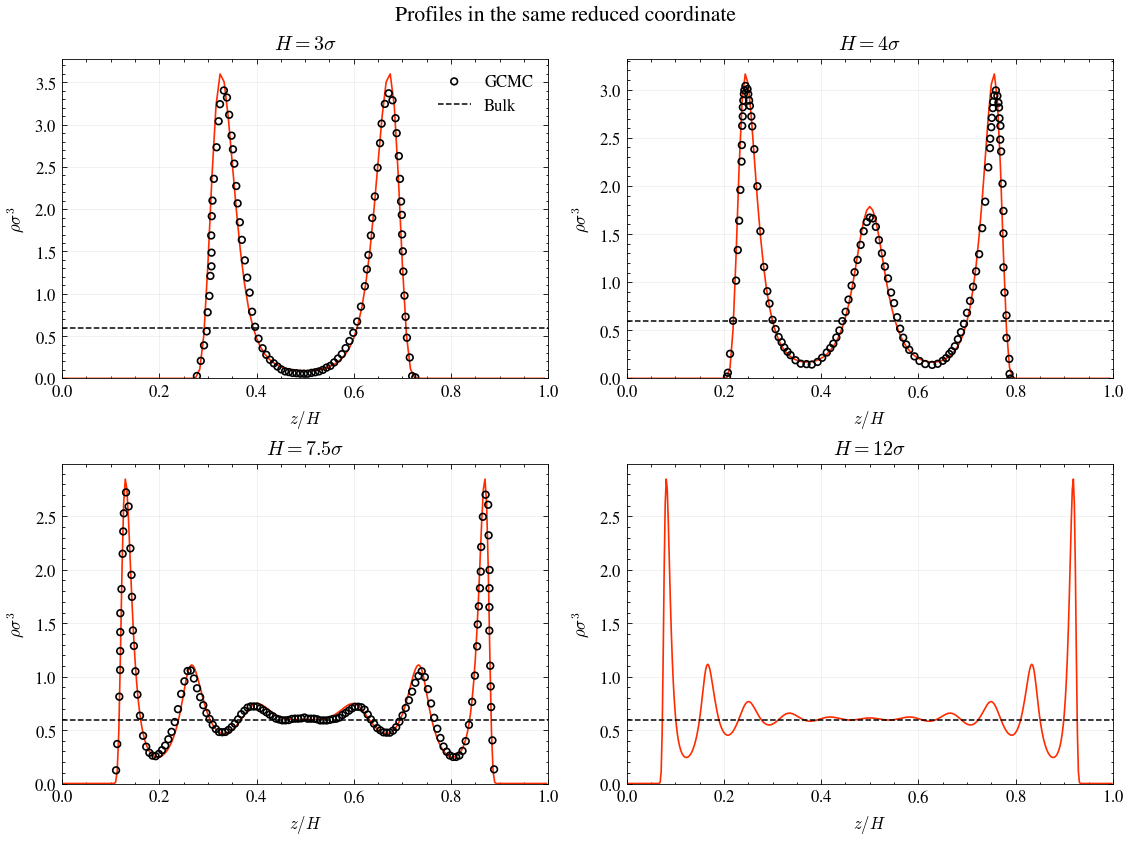

In [ ]:
# GCMC points are available for these widths at the same thermodynamic condition.
mc_por_H = {}
for H in [3.0, 4.0, 7.5]:
    nome = f"lj-slitpore-steele-T1.2-rhob0.5925-H{H:.1f}-GEMC.dat"
    arquivo = dados / nome
    if not arquivo.exists():
        urlretrieve(f"{RAW}/examples/data/MC/{nome}", arquivo)
    mc_por_H[H] = np.loadtxt(arquivo)

fig, axes = plt.subplots(2, 2, figsize=(9.4, 7.0), constrained_layout=True)
for ax, H in zip(axes.flat, [3.0, 4.0, 7.5, 12.0]):
    z, rho_z = perfis[H]
    dentro = (z >= 0) & (z <= H)
    ax.plot(z[dentro]/H, rho_z[dentro], color="C3")
    if H in mc_por_H:
        mc = mc_por_H[H]
        ax.scatter(mc[:, 0]/H, mc[:, 1], s=16, facecolors="none",
                   edgecolors="k", label="GCMC", zorder=3)
    ax.axhline(0.5925, color="k", ls="--", lw=0.9, label="Bulk")
    ax.set(title=fr"$H={H:g}\sigma$", xlabel=r"$z/H$", ylabel=r"$\rho\sigma^3$",
           xlim=(0, 1), ylim=(0, None))
axes[0, 0].legend(frameon=False)
fig.suptitle("Profiles in the same reduced coordinate", fontsize=13)
plt.savefig("v6_perfis_por_largura.png", dpi=220, bbox_inches="tight")
plt.show()


The next plot tracks the central density relative to the bulk. The approach may oscillate with the number of layers; we do not expect a monotonic trend.

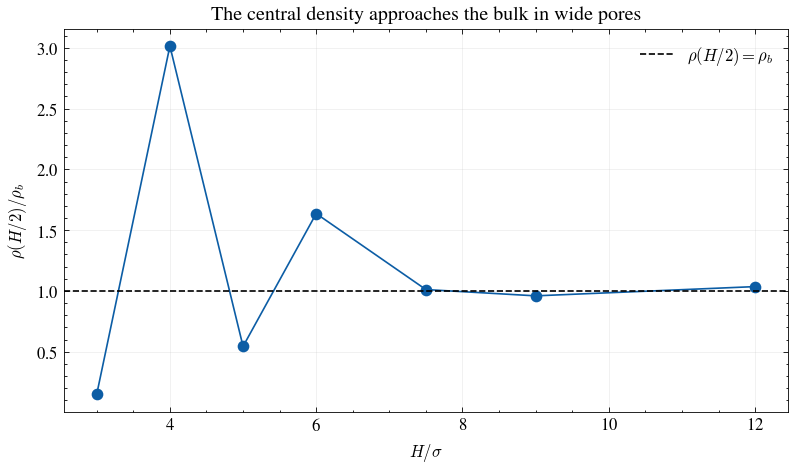

In [ ]:
fig, ax = plt.subplots(figsize=(6.6, 3.9), constrained_layout=True)
ax.plot(centro["H/sigma"], centro["Center/bulk ratio"], "o-", color="C0")
ax.axhline(1, color="k", ls="--", lw=1, label=r"$\rho(H/2)=\rho_b$")
ax.set(xlabel=r"$H/\sigma$", ylabel=r"$\rho(H/2)/\rho_b$",
       title="The central density approaches the bulk in wide pores")
ax.legend(frameon=False)
plt.show()


### 8.1 1D checkpoint

You now know how to change the functional, modify the wall potential, configure the solver, and verify convergence. To adapt the example, change **one choice at a time** and retain the previous benchmark.

## 9. 1D isotherm: N₂ in carbon at 100 K and hysteresis

Here an isotherm stops being a list of independent calculations. We follow the converged profile while **increasing** the pressure and then while **decreasing** it. Different local minima may produce a hysteresis loop.

We use an effective **one-site N₂**, without orientation or quadrupole. Parameters: $\sigma=3.615$ Å, $\epsilon/k_B=101.5$ K; N₂–carbon cross parameters $\sigma_{sf}=3.494$ Å, $\epsilon_{sf}/k_B=53.22$ K, $\rho_s=0.114$ Å⁻³, and $\Delta=3.35$ Å. These are the LJ–MC parameters discussed by [Ravikovitch et al., Langmuir (2000), Table 1](https://doi.org/10.1021/la991011c), used here with the PyDFTlj functional—not a reproduction of the NLDFT treatment in that article.

We choose $H=7.5\sigma$, within the suggested range. The model is useful for discussing capillary filling; quantitative calibration for real N₂ requires additional validation.

### 9.1 The reservoir below the critical temperature

The EOS may have multiple densities at the same pressure. We first determine coexistence from $\mu(\rho_v,T)=\mu(\rho_l,T)$ and $P(\rho_v,T)=P(\rho_l,T)$. During the sweep, the root is always sought **on the vapor branch**, below $P_{sat}$.

In [ ]:
from scipy.optimize import root, brentq

sigma, epsilon, T = 3.615, 101.5, 100.0  # Effective N2: Å, K, K
eos_n2 = LJEOS(sigma=sigma, epsilon=epsilon)

def coexistencia(x):
    rv, rl = torch.tensor(x/sigma**3, dtype=torch.float64)
    return [float(eos_n2.mu(rv, T)-eos_n2.mu(rl, T))/epsilon,
            float(eos_n2.p(rv, T)-eos_n2.p(rl, T))*sigma**3/epsilon]

elv = root(coexistencia, np.array([0.02, 0.72]))  # Reduced-density guesses.
rho_v, rho_l = elv.x / sigma**3
if not elv.success or not 0 < rho_v < rho_l:
    raise RuntimeError("Bulk coexistence was not found; review the guesses.")
psat = float(eos_n2.p(torch.tensor(rho_v, dtype=torch.float64), T)) * K_A3_para_bar
print(f"Model Psat: {psat:.4f} bar; T* = {T/epsilon:.4f}")
print(f"Reduced densities: vapor = {rho_v*sigma**3:.5f}; liquid = {rho_l*sigma**3:.5f}")


Model Psat: 6.6538 bar; T* = 0.9852
Reduced densities: vapor = 0.02653; liquid = 0.71072


We build the slit in dimensional units. The potential from each wall uses the N₂–carbon cross parameters. The buffer isolates periodic images, as in the reduced-unit example.

**To fit within the class:** we calculate only 1–3 bar, with local refinement between 1.725 and 1.975 bar. We retain the spatial grid, functional, and tolerance. The previous sweep had 89 pressures; now there are 30. Picard uses `alpha=0.03` (previously 0.02), validated for this case, and continues from the preceding solution. This reduces work without replacing the procedure for following local minima with a solver that might switch branches. For a quantitative study, refine the pressure near the jumps and the crossing of Ω.

In [ ]:
H = 7.5 * sigma      # Distance between the outer carbon planes.
buffer = 5 * sigma
n2 = DFT(functional="aWBI+MMFA", device=DEVICE_1D)
n2.set_fluid_properties(sigma=sigma, epsilon=epsilon, mass=28.0134, cut_off=5*sigma)
n2.set_gridsize(0.04*sigma)
n2.set_geometry(lengths=H + 2*buffer)
n2._from_ase = False
z = np.squeeze(n2.X) - buffer

sigma_sf, epsilon_sf = 3.494, 53.22
delta, rho_s = 3.35, 0.114
prefator = 2*np.pi*rho_s*delta*epsilon_sf*sigma_sf**2
dentro = (z > 0.02*sigma) & (z < H - 0.02*sigma)
V = np.full_like(z, np.inf)
V[dentro] = (steele(z[dentro], prefator, sigma_sf, delta)
              + steele(H-z[dentro], prefator, sigma_sf, delta))
n2.set_external_potential(V.reshape(n2.Ngrid))
n2.set_temperature(T)

# Classroom mode: only 1–3 bar, with more points in the hysteresis region.
p_n2 = np.unique(np.round(np.r_[np.linspace(1.0, 3.0, 21),
                               np.arange(1.725, 1.976, 0.025)], 6))
if not np.all((p_n2 > 0) & (p_n2 < psat)):
    raise ValueError("The pressure range must remain on the vapor branch below Psat.")
print(f"{len(p_n2)} pressures; {2*len(p_n2)} states in the two sweeps")
rho_reservatorio = np.array([
    brentq(lambda r: float(eos_n2.p(torch.tensor(r, dtype=torch.float64), T))
                     * K_A3_para_bar - p, 1e-12, rho_v)
    for p in p_n2
])


Grid defined!
Lgrid = (np.float32(63.2625), np.float32(0.1446), np.float32(0.1446))  A
X-axis = [ 0.0 , 63.2625 ] A
Y-axis = [ 0.0 , 0.1446 ] A
Z-axis = [ 0.0 , 0.1446 ] A
Number of gridpoints = (438, 1, 1)
delta =  [0.1446 0.1446 0.1446]  A
Vol = 1.3227658  A³
30 pressures; 60 states across both sweeps


### 9.2 Two sweep directions

We use Picard with small mixing to follow each local branch. Adsorption starts dilute; desorption starts from a dense guess at the highest pressure. The reservoir **remains vapor** in both sweeps: the liquid guess is only an initial density inside the pore.

In 1D, we report $\Gamma=N/A=\int\rho(z)dz$ in molecules/nm² and $\beta\Omega\sigma^2/A$. The numerical area is `dV/delta[0]`; dividing by it removes the artificial transverse thickness of the 1D object. Excess adsorption uses the geometric volume $AH$ explicitly.

In [ ]:
ramos = []
inicio_isoterma = time.perf_counter()
for nome, indices, chute in [
    ("Adsorption", range(len(p_n2)), 1e-6),
    ("Desorption", range(len(p_n2)-1, -1, -1), rho_l),
]:
    n2.set_bulk_density(chute)
    n2.set_initial_condition("bulk")
    for passo, j in enumerate(indices, start=1):
        n2.set_bulk_density(rho_reservatorio[j])
        n2.update_system()
        opt = Optimizer.create("picard", n2, alpha=0.03,
                               atol=1e-8, rtol=1e-4, max_iter=18000)
        opt.run()
        if not opt.converged:
            raise RuntimeError(f"{nome}, P={p_n2[j]:.4f} bar: {opt.stop_reason}")
        if passo == 1 or passo % 5 == 0 or passo == len(p_n2):
            print(f"{nome}: {passo}/{len(p_n2)} · P={p_n2[j]:.3f} bar · {opt.Niter} iterations", flush=True)
        area = float(n2.dV/n2.delta[0])
        gamma = float(n2.Nabs)/area
        omega = float(n2.Omega)*sigma**2/(T*area)
        ramos.append([nome, p_n2[j], gamma*100,
                      (gamma-rho_reservatorio[j]*H)*100, omega, opt.Niter, opt.error])

iso_n2 = pd.DataFrame(ramos, columns=["Branch", "Pressure (bar)", "N/A (nm⁻²)",
                                     "Excess/A (nm⁻²)", "Reduced Omega per area", "Iterations", "Error"])
iso_n2.to_csv("v6_isoterma_N2_100K.csv", index=False)
display(iso_n2.groupby("Branch").agg(Points=("Error", "size"), Maximum_error=("Error", "max")))

print(f"Total time: {time.perf_counter()-inicio_isoterma:.1f} s")


Adsorption: 1/30 · P=1.000 bar · 488 iterations
Adsorption: 5/30 · P=1.400 bar · 271 iterations
Adsorption: 10/30 · P=1.750 bar · 250 iterations
Adsorption: 15/30 · P=1.875 bar · 333 iterations
Adsorption: 20/30 · P=2.000 bar · 3135 iterations
Adsorption: 25/30 · P=2.500 bar · 137 iterations
Adsorption: 30/30 · P=3.000 bar · 119 iterations
Desorption: 1/30 · P=3.000 bar · 395 iterations
Desorption: 5/30 · P=2.600 bar · 130 iterations
Desorption: 10/30 · P=2.100 bar · 153 iterations
Desorption: 15/30 · P=1.900 bar · 106 iterations
Desorption: 20/30 · P=1.775 bar · 194 iterations
Desorption: 25/30 · P=1.500 bar · 284 iterations
Desorption: 30/30 · P=1.000 bar · 278 iterations


,Points,Maximum_error
Branch,,
Adsorption,30,0.999488
Desorption,30,0.999335


Total time: 127.3 s


### 9.3 Which profile is more stable?

At the same pressure, temperature, geometry, and $\mu$ convention, we compare Ω for the two converged solutions. The lower Ω identifies the more stable state **among the solutions found**. Coexistence requires equal Ω; a jump during a sweep marks loss of persistence of a branch and does not by itself determine the equilibrium pressure.

We show the isotherm, Ω versus pressure, and the difference $\Omega_{des}-\Omega_{ads}$. The difference makes the crossing easier to see. Pressure resolution and tolerance should be refined near it.

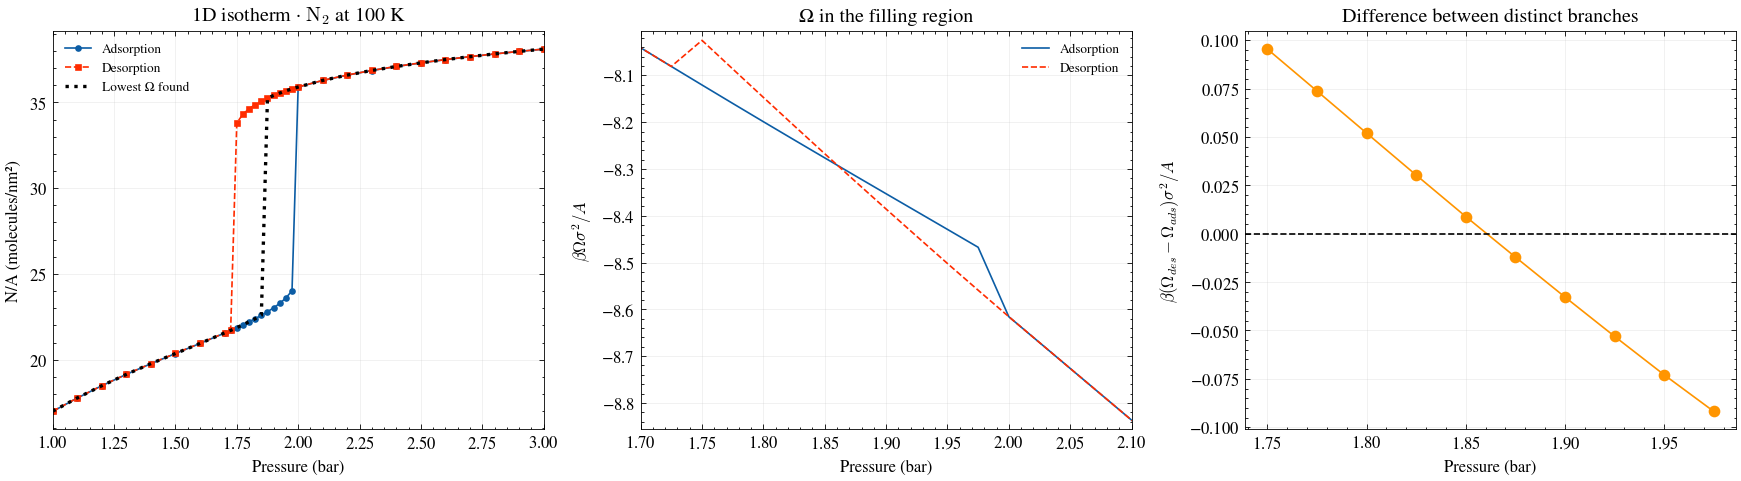

Estimated crossing: 1.8606 bar (P/Psat = 0.2796)


In [ ]:
ads = iso_n2.query("Branch == 'Adsorption'").sort_values("Pressure (bar)")
des = iso_n2.query("Branch == 'Desorption'").sort_values("Pressure (bar)")
p = ads["Pressure (bar)"].to_numpy()
g_ads, g_des = ads["N/A (nm⁻²)"].to_numpy(), des["N/A (nm⁻²)"].to_numpy()
w_ads = ads["Reduced Omega per area"].to_numpy()
w_des = des["Reduced Omega per area"].to_numpy()
distintos = np.abs(g_des-g_ads) > 0.1
delta_omega = w_des-w_ads

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4), constrained_layout=True)
ax[0].plot(p, g_ads, "o-", ms=3, label="Adsorption", color="C0")
ax[0].plot(p, g_des, "s--", ms=3, label="Desorption", color="C3")
ax[0].plot(p, np.where(w_ads <= w_des, g_ads, g_des), "k:", lw=2, label="Lowest Ω found")
ax[0].set(ylabel="N/A (molecules/nm²)", title=r"1D isotherm · $\mathrm{N_2}$ at 100 K", xlim=(1, 3))
ax[1].plot(p, w_ads, color="C0", label="Adsorption")
ax[1].plot(p, w_des, "--", color="C3", label="Desorption")
ax[1].set(ylabel=r"$\beta\Omega\sigma^2/A$", title="Grand potential")
zoom = (p/psat >= 0.25) & (p/psat <= 0.32)
ax[1].set_xlim(p[zoom].min(), p[zoom].max())
ax[1].set_ylim(min(w_ads[zoom].min(), w_des[zoom].min())-0.02,
               max(w_ads[zoom].max(), w_des[zoom].max())+0.02)
ax[1].set_title("Ω in the filling region")
ax[2].plot(p[distintos], delta_omega[distintos], "o-", color="C2")
ax[2].axhline(0, color="k", ls="--", lw=1)
ax[2].set(ylabel=r"$\beta(\Omega_{des}-\Omega_{ads})\sigma^2/A$", title="Difference between distinct branches")
for eixo in ax:
    eixo.set_xlabel("Pressure (bar)")
for eixo in ax[:2]: eixo.legend(frameon=False, fontsize=8)
plt.savefig("v6_histerese_N2.png", dpi=220, bbox_inches="tight")
plt.show()

cruza = np.flatnonzero(distintos[:-1] & distintos[1:] & (delta_omega[:-1]*delta_omega[1:] < 0))
for j in cruza:
    p_eq = p[j] - delta_omega[j]*(p[j+1]-p[j])/(delta_omega[j+1]-delta_omega[j])
    print(f"Estimated crossing: {p_eq:.4f} bar (P/Psat = {p_eq/psat:.4f})")
if not len(cruza):
    print("No resolved crossing between distinct branches; refine pressure/tolerance before drawing a conclusion.")


# Exercise 2: Argon ($\text{Ar}$) adsorption isotherms and capillary condensation at $87\text{ K}$

#### Objective
Calculate complete adsorption and desorption isotherms for gaseous argon ($\text{Ar}$) at $T=87\text{ K}$ in slits of reduced widths $H=4\,\sigma$ and $H=10\,\sigma$, from low pressures up to $1\text{ bar}$.

From the density profiles and thermodynamic curves:
1. **Plot the adsorption and desorption isotherms:** Identify the metastable branches generated by the continuation algorithm (continuation from the dilute state for adsorption and from the condensed state for desorption).
2. **Use the grand potential to determine the equilibrium isotherm.**
3. **Compare the effect of confinement ($H=4\,\sigma$ vs. $H=10\,\sigma$):** Analyze how pore width changes the hysteresis-loop width and the magnitude of the condensation-pressure reduction relative to saturation in the bulk.

---

#### Suggested procedure
- **Pressure sweep:** Build a fine pressure grid in the capillary-transition region to resolve the crossing of $\Omega$.
- **Equilibrium criterion:** The true first-order transition occurs where $\Omega_{\mathrm{ads}}(P)=\Omega_{\mathrm{des}}(P)$.
- **Expected plots for each $H$ (three panels):**
  - **Panel 1:** $N/A$ (or $\Gamma$) isotherm versus $P$, highlighting the adsorption and desorption branches and the vertical thermodynamic-transition line (lower $\Omega$).
  - **Panel 2:** Reduced grand potential $\beta\Omega\sigma^2/A$ near capillary condensation.
  - **Panel 3:** Branch difference $\Delta\Omega=\beta(\Omega_{\mathrm{des}}-\Omega_{\mathrm{ads}})\sigma^2/A$ versus $P$, highlighting the zero crossing.

**Additional data for execution:** use LJ Ar from Exercise 1, Steele carbon ($\sigma_C=3.4$ Å; $\epsilon_C/k_B=28$ K), Lorentz–Berthelot combining rules, solid density 0.114 Å⁻³, and $\Delta=3.35$ Å. Calculate $P_{sat}$ from the adopted EOS: if it is below 1 bar, explicitly distinguish metastable vapor above $P_{sat}$. The Ω comparison is between states found in the same reservoir.

In [ ]:
# Exercise 2 resolution





# Part C — From 1D Steele to 3D atomistic carbon

## 10. CH₄ in a carbon slit built with ASE

The 3D wall is now made of **carbon atoms**, and its potential is calculated with `calculate_external_potential_lj`, the same method later used for the MOF. We do not replicate the Steele expression on the lateral planes.

We compare the lateral average $\langle\rho(x,y,z)\rangle_{xy}$ of the 3D solution with a **1D Steele** solution. Fluid, temperature, reservoir, cross parameters, carbon surface density, and layer spacing are shared.

### 10.1 Parameters and correspondence with Steele

The examples in part B used a generic LJ wall in reduced units. Here we repeat the 1D procedure with dimensional **CH₄–carbon** parameters to match the physical slab: TraPPE CH₄, carbon from `examples/parameters/Steele-forcefield.dat`, graphene with $a=2.46$ Å, and layers spaced by $\Delta=3.35$ Å. We do not silently equate the previous reduced wall with graphite.

$$\sigma_{sf}=\tfrac12(\sigma_f+\sigma_C),\qquad\epsilon_{sf}=\sqrt{\epsilon_f\epsilon_C},\qquad
\rho_A=\frac{N_{C,\mathrm{layer}}}{A},\qquad\rho_s=\frac{\rho_A}{\Delta},\qquad
\epsilon_w=2\pi\rho_A\epsilon_{sf}\sigma_{sf}^2.$$

We build six AB layers in an **orthorhombic** supercell. The slit is the space between the last layer and the first layer of the next periodic image. Thus, **one slab per cell creates both slit walls**, without duplicating atoms on the faces. The wall normal is the **Z** axis, and the lateral average uses `axis=(0,1)`.

Implementation references: [graphene in ASE](https://docs.ase-lib.org/_modules/ase/build/surface.html#graphene), [make_supercell](https://docs.ase-lib.org/_modules/ase/build/supercells.html#make_supercell), and [carbon parameters in PyDFTlj](https://github.com/elvissoares/PyDFTlj/blob/16e7d4349e22d3ead8774a332011b4c3d21806cd/examples/parameters/Steele-forcefield.dat).

In [ ]:
from ase import Atoms
from ase.build import graphene, make_supercell
from ase.io import write
from ase.visualize.plot import plot_atoms

sigma_c, epsilon_c, mass_c = 3.73, 148.0, 16.043  # CH4: Å, K, u
T_c, p_c = 300.0, 10.0                         # K, bar
a_c, delta_c, ncamadas = 2.46, 3.35, 6
H_c = 7.5*sigma_c
espessura_c = (ncamadas-1)*delta_c
Lz_c = espessura_c + H_c

ff_c = dados / "Steele-forcefield.dat"
if not ff_c.exists():
    urlretrieve(f"{RAW}/examples/parameters/{ff_c.name}", ff_c)
param_c = pd.read_csv(ff_c, sep=r"\s+").set_index("atom").loc["C"]
sigma_sf_c = 0.5*(sigma_c + param_c["sigma/AA"])
epsilon_sf_c = np.sqrt(epsilon_c*param_c["epsilon/kB"])

primitiva = graphene(a=a_c, vacuum=1.0)
primitiva.positions[:, 2] = 0.0
# The integer vector combination transforms the hexagonal cell into a rectangular cell.
folha = make_supercell(primitiva, [[1,0,0], [1,2,0], [0,0,1]]).repeat((12,7,1))
slab_c = Atoms()
for k in range(ncamadas):
    camada = folha.copy()
    camada.positions[:, 2] = k*delta_c
    if k % 2:  # Bernal AB stacking.
        camada.positions[:, :2] += [a_c/2, a_c*np.sqrt(3)/6]
    slab_c += camada
slab_c.set_cell([folha.cell.lengths()[0], folha.cell.lengths()[1], Lz_c])
slab_c.set_pbc(True)
slab_c.wrap()
assert np.allclose(slab_c.cell.angles(), 90.0)

area_c = np.prod(slab_c.cell.lengths()[:2])
rho_A_c = len(folha)/area_c
rho_s_c = rho_A_c/delta_c
prefator_c = 2*np.pi*rho_A_c*epsilon_sf_c*sigma_sf_c**2
write("slab_carbono_AB.cif", slab_c)
print("Atoms:", len(slab_c), "· cell (Å):", slab_c.cell.lengths())
print(f"rho_A = {rho_A_c:.5f} Å⁻²; rho_s = {rho_s_c:.5f} Å⁻³")
print(f"sigma_sf = {sigma_sf_c:.3f} Å; epsilon_sf = {epsilon_sf_c:.3f} K")
print(f"H = {H_c:.3f} Å; T = {T_c:g} K; P = {p_c:g} bar")


Atoms: 2016 · cell (Å): [29.52       29.82591491 44.725     ]
rho_A = 0.38162 Å⁻²; rho_s = 0.11392 Å⁻³
sigma_sf = 3.565 Å; epsilon_sf = 64.374 K
H = 27.975 Å; T = 300 K; P = 10 bar


### 10.2 Inspect the structure before the potential

The top view shows the carbon lattice; the side view shows the slab and slit. Periodicity in the Z direction places a new wall at the top of the cell even though it does not appear as a second copy of the atoms in this visualization.

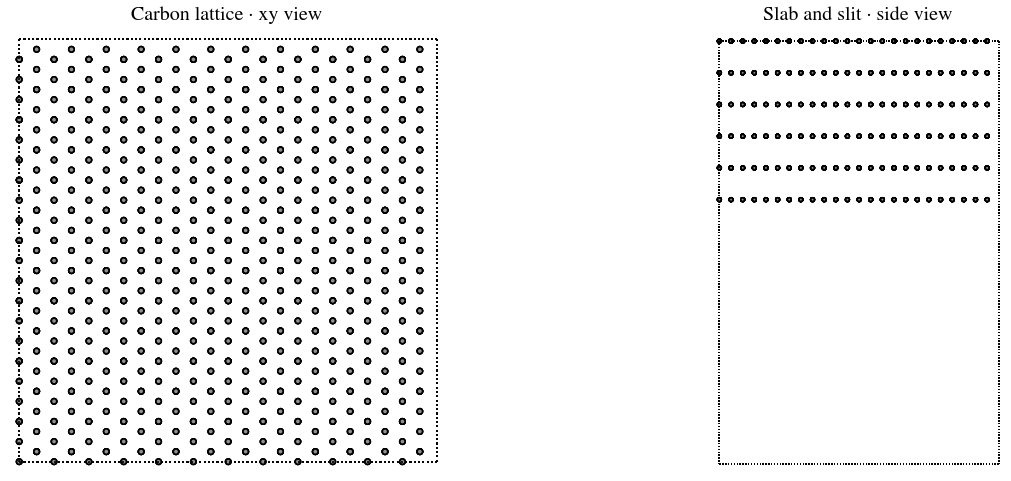

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)
for eixo, rotacao, titulo in zip(ax, ["0x,0y,0z", "90x,0y,0z"],
                               ["Carbon lattice · xy view", "Slab and slit · side view"]):
    plot_atoms(slab_c, eixo, rotation=rotacao, show_unit_cell=2, radii=0.25)
    eixo.set_title(titulo)
    eixo.set_axis_off()
plt.show()


### 10.3 Atomistic potential, minimum image, and cutoff

We use `set_geometry_from_ase(slab_c)` and the repository LJ helper. It applies the minimum-image convention in all three directions and sums the carbon–CH₄ pairs. The FFTs are also periodic.

$$V^{3D}_{ext}(\mathbf r)=\sum_a 4\epsilon_{sf}\left[\left(\frac{\sigma_{sf}}{r_a^{MIC}}\right)^{12}-\left(\frac{\sigma_{sf}}{r_a^{MIC}}\right)^6\right]\mathbf1_{r_a^{MIC}<r_c}.$$

We choose $r_c=4\sigma_{sf}$ and verify $r_c\leq\min(L_x,L_y,L_z)/2$. The supercell is large enough laterally to satisfy this condition; we do not use a small primitive cell with a range greater than half the box.

**Two conventions in the same package argument:** during the atomistic sum, `cut_off=4.0` means $4\sigma_{sf}$. After building Vext, we set `cut_off=5*sigma_c` for the **fluid–fluid** kernel, which receives a length. This second call does not recalculate Vext. All of this setup occurs before `set_temperature`.

The region occupied by the solid is explicitly excluded, and the same exclusion is used in the 1D controls. In this example the LJ potential already makes it inaccessible; the code shows how many internal nodes would be accessible before exclusion.

**How to interpret a difference from Steele:** Steele uses continuous layers and an approximation for a semi-infinite solid. The slab uses atoms, six layers, and a cutoff. To separate these differences, we include a 1D control: the same layers integrated over the plane and truncated at the same range.

For a layer at distance $h<r_c$, this control is the integral of the same LJ pair potential over the accessible disk:

$$V_{\mathrm{layer}}(h)=2\pi\rho_A\epsilon_{sf}\sigma_{sf}^{2}\left[\frac25\left(\frac{\sigma_{sf}}h\right)^{10}-\left(\frac{\sigma_{sf}}h\right)^4-\frac25\left(\frac{\sigma_{sf}}{r_c}\right)^{10}+\left(\frac{\sigma_{sf}}{r_c}\right)^4\right],$$

with $V_{\mathrm{layer}}=0$ for $h\geq r_c$. We sum the layers using the minimum-image convention in Z. The result should approximate the **lateral average of the atomistic potential**, without assuming exact equality between the densities: solving cDFT and taking a lateral average are not interchangeable operations.

In [ ]:
CUT_SF_C = 4.0
rc_sf_c = CUT_SF_C*sigma_sf_c
assert rc_sf_c <= 0.5*slab_c.cell.lengths().min(), "Increase the lateral supercell."
N_C = np.array([48, 48, 128])
passo_c = np.nextafter((slab_c.cell.lengths()/N_C).astype(np.float32), np.float32(np.inf))

slab_dft = DFT(functional="aWBI+MMFA", device=DEVICE)
slab_dft.set_fluid_properties(sigma=sigma_c, epsilon=epsilon_c, mass=mass_c, cut_off=CUT_SF_C)
slab_dft.set_gridsize(passo_c)
slab_dft.set_geometry_from_ase(slab_c)
with np.errstate(over="ignore"):
    slab_dft.calculate_external_potential_lj(forcefield_path=ff_c)
V_atom_c = slab_dft.Vext.detach().cpu().numpy().copy()  # Raw field before capping V/T.
z_abs_c = slab_dft.z.copy()
z_c = z_abs_c-espessura_c
poro_c = (z_c > 0) & (z_c < H_c)
print("Accessible nodes inside the slab before exclusion:",
      np.count_nonzero((V_atom_c/T_c < 36.8) & ~poro_c[None,None,:]))
V_calc_c = V_atom_c.copy()
V_calc_c[:, :, ~poro_c] = np.inf
slab_dft.set_external_potential(V_calc_c)
# cut_off is now the fluid–fluid kernel length; Vext is preserved.
slab_dft.set_fluid_properties(sigma=sigma_c, epsilon=epsilon_c, mass=mass_c, cut_off=5*sigma_c)
slab_dft.set_temperature(T_c)
rho_res_c = float(slab_dft.calculate_rho_from_pbar(np.array([p_c]))[0])

V_steele_c = np.full_like(z_c, np.inf)
V_steele_c[poro_c] = (steele(z_c[poro_c], prefator_c, sigma_sf_c, delta_c)
                      + steele(H_c-z_c[poro_c], prefator_c, sigma_sf_c, delta_c))
V_planos_c = np.zeros_like(z_c)
for z_camada in np.arange(ncamadas)*delta_c:
    h = z_abs_c-z_camada
    h -= Lz_c*np.round(h/Lz_c)
    h = np.maximum(np.abs(h), 1e-6)
    v = prefator_c*(0.4*(sigma_sf_c/h)**10-(sigma_sf_c/h)**4
                    -0.4*(sigma_sf_c/rc_sf_c)**10+(sigma_sf_c/rc_sf_c)**4)
    V_planos_c += np.where(h < rc_sf_c, v, 0.0)
V_planos_c[~poro_c] = np.inf
print(f"Solid–fluid cutoff: {rc_sf_c:.3f} Å; half the shortest box length: {slab_c.cell.lengths().min()/2:.3f} Å")
print("3D grid:", slab_dft.Ngrid, "· rho_b (Å⁻³):", rho_res_c)


Geometry defined from ASE atoms object:
Lx=29.52 A, Ly=29.83 A, Lz=44.73 A
Unit cell Volume = 39378.62 A³
Solid Mass = 24214.18 u
Solid Mass Density = 0.6149 u/A³
Grid defined!
Lgrid = (np.float64(29.52), np.float64(29.825914906336067), np.float64(44.725))  A
X-axis = [ 0.0 , 29.52 ] A
Y-axis = [ 0.0 , 29.825914906336067 ] A
Z-axis = [ 0.0 , 44.725 ] A
Number of gridpoints = (48, 48, 128)
delta =  [0.61500007 0.6213733  0.34941408]  A
Vol = 39378.61858436719  A³
Accessible nodes within the slab before exclusion: 0
Solid–fluid cutoff: 14.260 Å; half the shortest box length: 14.760 Å
Grid 3D: (48, 48, 128) · rho_b (Å⁻³): 0.00024529466597598027


### 10.4 Compare the potentials before the densities

The first panel compares Steele, the atomistic lateral average, and continuous layers with the same cutoff. The shaded band shows the lateral variation of the atomistic potential. The second panel is an actual 3D slice; the scale is clipped only to visualize the adsorption region, without changing the field used in the calculation.

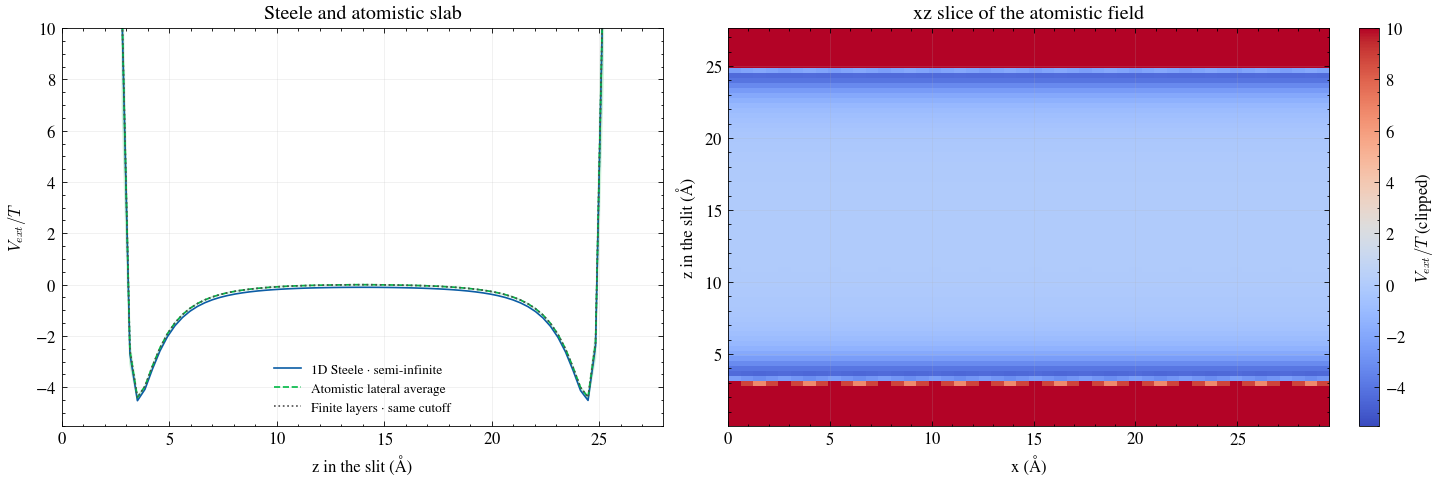

In [ ]:
V_media_c = V_atom_c.mean(axis=(0,1))
fig, ax = plt.subplots(1, 2, figsize=(12.0, 4.0), constrained_layout=True)
ax[0].plot(z_c[poro_c], V_steele_c[poro_c]/T_c, label="1D Steele · semi-infinite")
ax[0].plot(z_c[poro_c], V_media_c[poro_c]/T_c, "--", label="Atomistic lateral average")
ax[0].plot(z_c[poro_c], V_planos_c[poro_c]/T_c, ":", color="0.3", label="Finite layers · same cutoff")
ax[0].fill_between(z_c[poro_c], V_atom_c.min(axis=(0,1))[poro_c]/T_c,
                    V_atom_c.max(axis=(0,1))[poro_c]/T_c, color="C1", alpha=0.15)
ax[0].set(xlim=(0,H_c), ylim=(-5.5,10), xlabel="z in the slit (Å)", ylabel=r"$V_{ext}/T$",
          title="Steele and atomistic slab")
ax[0].legend(frameon=False, fontsize=8)
im = ax[1].imshow(np.clip(V_atom_c[:, slab_dft.Ngrid[1]//2, :][:,poro_c].T/T_c, -5.5, 10),
                   origin="lower", aspect="auto", extent=(0,slab_c.cell.lengths()[0],z_c[poro_c].min(),z_c[poro_c].max()),
                   cmap="coolwarm", vmin=-5.5, vmax=10)
ax[1].set(xlabel="x (Å)", ylabel="z in the slit (Å)", title="xz slice of the atomistic field")
fig.colorbar(im, ax=ax[1], label=r"$V_{ext}/T$ (clipped)")
plt.show()


### 10.5 Solve the 1D and 3D cDFT problems

All three solutions use `aWBI+MMFA`, $T=300$ K, $P=10$ bar, the same fluid–fluid cutoff, the same grid in the normal direction, and the same tolerance. The atomistic profile is solved in 3D starting from the bulk. We do not use the 1D solution as the initial guess.

To compare adsorbed amounts, we calculate $N/A$, not N, because the artificial area of the 1D object is not the slab area. We retain the finite-layer control as a diagnostic of the difference between the slab and Steele.

In [ ]:
resultados_c, resumo_c = {}, []
for nome, V_1d in [("Steele 1D", V_steele_c), ("1D finite layers", V_planos_c), ("3D atomistic slab", None)]:
    if V_1d is None:
        sistema_c = slab_dft
    else:
        sistema_c = DFT(functional="aWBI+MMFA", device=DEVICE_1D)
        sistema_c.set_fluid_properties(sigma=sigma_c, epsilon=epsilon_c, mass=mass_c, cut_off=5*sigma_c)
        sistema_c.set_gridsize(float(slab_dft.delta[2]))
        sistema_c.set_geometry(Lz_c)
        sistema_c._from_ase = False
        sistema_c.set_external_potential(V_1d.reshape(sistema_c.Ngrid))
        sistema_c.set_temperature(T_c)
    sistema_c.set_bulk_density(rho_res_c)
    sistema_c.set_initial_condition("bulk")
    opt_c = Optimizer.create("picard", sistema_c, alpha=0.20,
                            atol=1e-7, rtol=1e-4, max_iter=2000)
    inicio = time.perf_counter()
    opt_c.run()
    if not opt_c.converged:
        raise RuntimeError(f"{nome}: {opt_c.stop_reason}; error={opt_c.error:.3g}")
    rho_c = sistema_c.rho.detach().cpu().numpy().copy()
    media_c = rho_c.mean(axis=(0,1)) if V_1d is None else rho_c.squeeze()
    area_num = (np.prod(sistema_c.Ngrid[:2])*sistema_c.delta[0]*sistema_c.delta[1]
                if V_1d is None else sistema_c.dV/sistema_c.delta[0])
    gamma_c = float(sistema_c.Nabs)/float(area_num)*100  # molecules/nm²
    resultados_c[nome] = {"media": media_c, "rho": rho_c, "Gamma": gamma_c}
    resumo_c.append([nome, gamma_c, opt_c.Niter, opt_c.error, time.perf_counter()-inicio])
display(pd.DataFrame(resumo_c, columns=["Wall model", "N/A (nm⁻²)", "Iterations", "Error", "Time (s)"]))


Grid defined!
Lgrid = (np.float32(44.725), np.float32(0.34941408), np.float32(0.34941408))  A
X-axis = [ 0.0 , 44.725 ] A
Y-axis = [ 0.0 , 0.34941408 ] A
Z-axis = [ 0.0 , 0.34941408 ] A
Number of gridpoints = (128, 1, 1)
delta =  [0.34941408 0.34941408 0.34941408]  A
Vol = 5.460484  A³
Grid defined!
Lgrid = (np.float32(44.725), np.float32(0.34941408), np.float32(0.34941408))  A
X-axis = [ 0.0 , 44.725 ] A
Y-axis = [ 0.0 , 0.34941408 ] A
Z-axis = [ 0.0 , 0.34941408 ] A
Number of gridpoints = (128, 1, 1)
delta =  [0.34941408 0.34941408 0.34941408]  A
Vol = 5.460484  A³


,Wall model,N/A (nm⁻²),Iterations,Error,Time (s)
0,Steele 1D,3.719819,37,0.813411,0.185530
1,Finite layers 1D,3.371301,36,0.941511,0.179534
2,Atomistic slab 3D,3.375890,36,0.941039,0.410068


### 10.6 Compare profiles and interpret the differences

The dashed line is the average of the 3D density. Proximity to the finite-layer control indicates how much of the difference from Steele comes from the interaction range and the semi-infinite representation. Atomistic corrugation may produce additional differences.

**Exercise:** increase `CUT_SF_C` and the lateral supercell together while respecting the minimum-image test. Also increase the number of layers if necessary. Repeat the entire setup and observe the approach to Steele. Refining only the grid does not recover an omitted interaction tail.

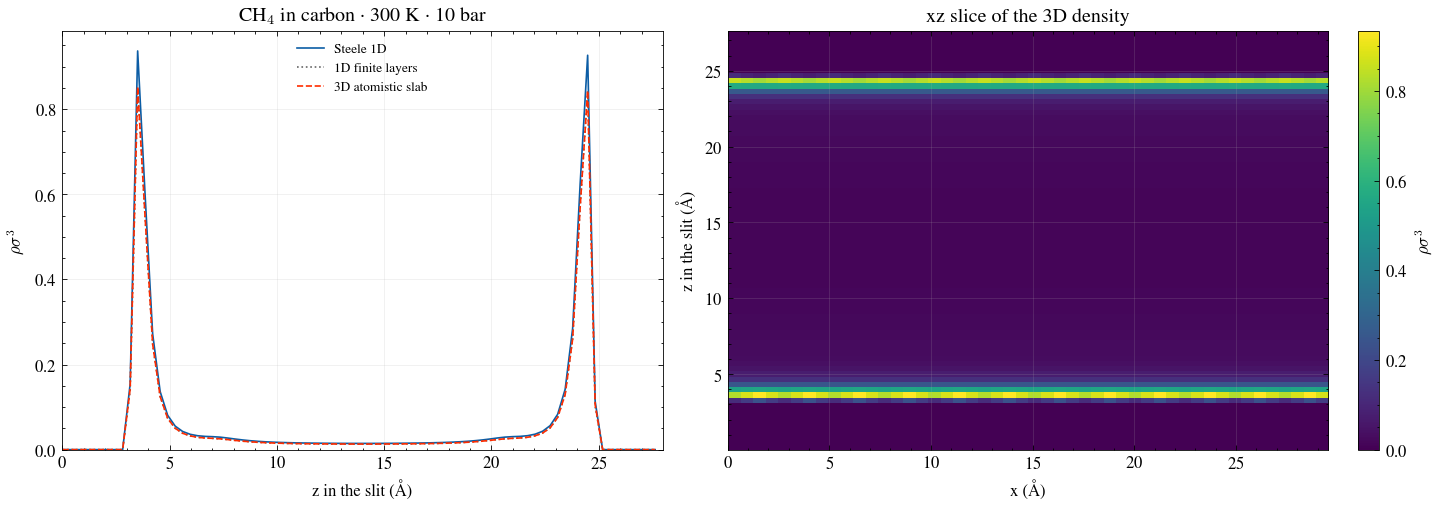

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True)
for (nome, resultado), estilo, cor in zip(resultados_c.items(), ["-", ":", "--"], ["C0","0.4","C3"]):
    ax[0].plot(z_c[poro_c], resultado["media"][poro_c]*sigma_c**3, estilo, color=cor, label=nome)
ax[0].set(xlabel="z in the slit (Å)", ylabel=r"$\rho\sigma^3$", xlim=(0,H_c), ylim=(0,None),
          title=r"CH$_4$ in carbon · 300 K · 10 bar")
ax[0].legend(frameon=False, fontsize=8)
rho_slab_c = resultados_c["3D atomistic slab"]["rho"]
im = ax[1].imshow(rho_slab_c[:, rho_slab_c.shape[1]//2, :][:,poro_c].T*sigma_c**3,
                   origin="lower", aspect="auto", extent=(0,slab_c.cell.lengths()[0],z_c[poro_c].min(),z_c[poro_c].max()),
                   cmap="viridis")
ax[1].set(xlabel="x (Å)", ylabel="z in the slit (Å)", title="xz slice of the 3D density")
fig.colorbar(im, ax=ax[1], label=r"$\rho\sigma^3$")
plt.savefig("v6_carbono_Steele_slab.png", dpi=220, bbox_inches="tight")
plt.show()


# Part D — CH₄ in IRMOF-1 from a CIF

## 11. Structure, force field, and external potential

The CIF describes atomic sites. The force field supplies $\sigma_s$ and $\epsilon_s$. The package helper applies Lorentz–Berthelot,

$$\sigma_{sf}=\frac{\sigma_s+\sigma_f}{2},\qquad
\epsilon_{sf}=\sqrt{\epsilon_s\epsilon_f},$$

and sums the LJ interaction from each atom at every grid point. Changing TraPPE changes the EOS and cross parameters; changing DREIDING to UFF changes only the solid–fluid interaction. The package does not include electrostatics or multisite molecules.

**Orthogonal cell required:** `set_geometry_from_ase` rejects CIFs with angles other than 90°. Simply changing the angles in the file is not enough: a valid transformation must preserve the structure and may require an equivalent orthogonal supercell.

### 11.1 Force-field choice

- **Fluid:** TraPPE-UA CH₄ is one LJ site with the molecular mass. A two-site N₂ model with a quadrupole cannot be transferred in full to this package.
- **Solid:** DREIDING and UFF are starting points. The helper table is indexed by element; it does not automatically distinguish hybridization, chemical environment, or different types of the same element.
- **Cross interactions:** record whether you use Lorentz–Berthelot or fitted cross parameters. For specific rules, build `Vext` explicitly and use `set_external_potential`.
- **Comparison:** retain the CIF, temperature, functional, cutoff, and grid when changing the force field. Validate density/structure, accessible volume, and isotherms with the same excess-adsorption definition as the reference.
- **Physical limitations:** charges, quadrupoles, orientational molecules, and solid flexibility are not represented. No set of LJ parameters automatically recovers these effects.

The next cell reads the CIF and reference data and restores the CH₄ parameters, because the previous example used N₂.

In [ ]:
sigma, epsilon, mass = 3.73, 148.0, 16.043  # CH4: Å, K, u

from ase.io import read
from ase.io.cube import write_cube
from ase.visualize import view
from ase.visualize.plot import plot_atoms
import py3Dmol

remotos = {
    "IRMOF-1.cif": "examples/structures/IRMOF-1.cif",
    "DREIDING-forcefield.dat": "examples/parameters/DREIDING-forcefield.dat",
    "UFF-forcefield.dat": "examples/parameters/UFF-forcefield.dat",
    "H2andCH4-MOFandZIF-isotherm-Zhou2007.xls": "examples/data/experimental/H2andCH4-MOFandZIF-isotherm-Zhou2007.xls",
    "CH4-MOF-isotherm-Keskin2016.xls": "examples/data/experimental/CH4-MOF-isotherm-Keskin2016.xls",
}
for nome, remoto in remotos.items():
    destino = dados / nome
    if not destino.exists():
        urlretrieve(f"{RAW}/{remoto}", destino)

estrutura = read(dados / "IRMOF-1.cif")
print("Formula:", estrutura.get_chemical_formula())
print("Atoms:", len(estrutura))
print("Cell (Å):", estrutura.cell.lengths())
print("Angles:", estrutura.cell.angles())


Formula: C192H96O104Zn32
Atoms: 424
Cell (Å): [25.86584 25.86584 25.86584]
Angles: [90. 90. 90.]


We project the structure onto the three planes to recognize atoms, channels, and symmetries before examining the external potential.

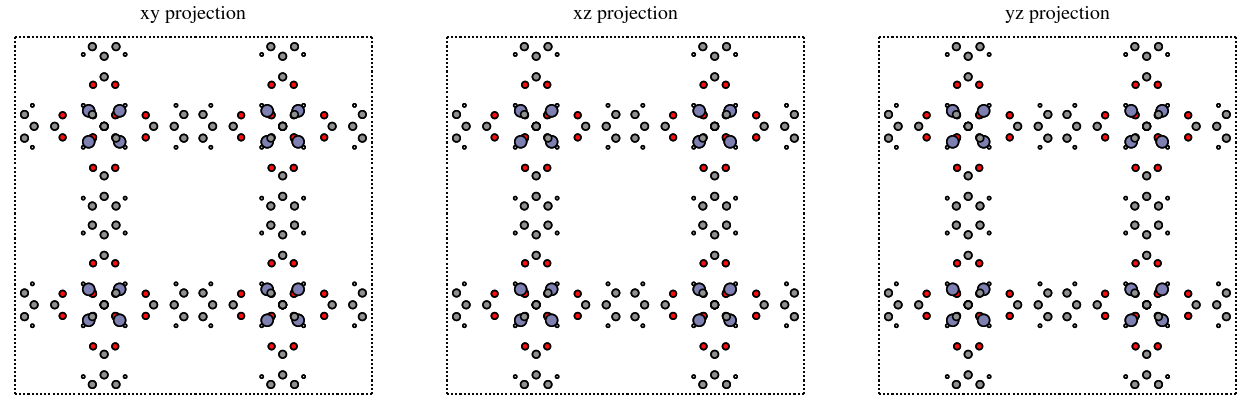

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10.8, 3.4), constrained_layout=True)
for eixo, rotacao, titulo in zip(
    ax,
    ["0x,0y,0z", "90x,0y,0z", "0x,90y,0z"],
    ["xy projection", "xz projection", "yz projection"],
):
    plot_atoms(estrutura, eixo, rotation=rotacao, show_unit_cell=2, radii=0.35)
    eixo.set_title(titulo)
    eixo.set_axis_off()
plt.show()


### 11.2 Interactive structure with ASE

Drag to rotate and use the wheel to zoom. Here we see **atoms and bonds**; next we will see $V_{ext}(\mathbf r)$, a scalar field derived from them.

In [ ]:
view(estrutura, viewer="x3d")


The table compares the CH₄–solid cross parameters from DREIDING and UFF for the elements present in the CIF. Choose the force field before building Vext.

In [ ]:
FORCEFIELD = "DREIDING"  # change to "UFF" and rebuild Vext
ff_path = dados / f"{FORCEFIELD}-forcefield.dat"
elementos = sorted(set(estrutura.get_chemical_symbols()))

tabelas = []
for nome in ["DREIDING", "UFF"]:
    ff = pd.read_csv(dados / f"{nome}-forcefield.dat", sep=r"\s+")
    ff = ff[ff["atom"].isin(elementos)].copy()
    ff["sigma_sf (Å)"] = 0.5 * (sigma + ff["sigma/AA"])
    ff["epsilon_sf (K)"] = np.sqrt(epsilon * ff["epsilon/kB"])
    ff.insert(0, "Force field", nome)
    tabelas.append(ff[["Force field", "atom", "sigma_sf (Å)", "epsilon_sf (K)"]])

display(pd.concat(tabelas).sort_values(["atom", "Force field"]).rename(columns={"atom": "Element", "sigma_sf (Å)": "Sigma sf (Å)", "epsilon_sf (K)": "Epsilon sf (K)"}).style.format({
    "Sigma sf (Å)": "{:.3f}", "Epsilon sf (K)": "{:.2f}"
}))


,Campo,Elemento,Sigma sf (Å),Epsilon sf (K)
1,DREIDING,C,3.601,84.16
1,UFF,C,3.580,88.43
0,DREIDING,H,3.288,33.65
0,UFF,H,3.151,57.24
3,DREIDING,O,3.382,84.42
3,UFF,O,3.424,66.85
9,DREIDING,Zn,3.887,64.00
5,UFF,Zn,3.096,96.10


### 11.3 How the structure becomes a scalar field

For each site in the CIF, `calculate_external_potential_lj` reads its symbol and position, looks up the parameters, applies Lorentz–Berthelot, and sums the LJ interaction at each node. A second sum with a He probe defines the accessible volume.

$$V_{ext}(\mathbf r)=\sum_{a\in\mathrm{cell}}u_{sf,a}\!\left(\lVert\Delta\mathbf r_a^{MIC}\rVert\right).$$

**Minimum-image convention (MIC).** The code replaces each separation component by

$$\Delta r_{a,\alpha}^{MIC}=r_\alpha-R_{a,\alpha}-L_\alpha\,\operatorname{round}\!\left(\frac{r_\alpha-R_{a,\alpha}}{L_\alpha}\right),\qquad \alpha=x,y,z.$$

This selects the nearest periodic image of **each atom in the cell**, rather than explicitly summing all crystal replicas. The helper applies periodicity in all three directions without checking `atoms.pbc` individually; setting `pbc=False` in ASE does not turn it into an isolated-surface calculation. The cDFT FFT convolutions are also periodic. In the slit, forbidden regions and a buffer separate the pores; in the MOF, we want the periodic structure.

**Orthorhombic cells only (90° angles).** Component-wise reduction assumes orthogonal axes; `set_geometry_from_ase` rejects angles other than 90°. Do not merely change the angles in the CIF. An equivalent orthogonal representation, when one exists, must have Cartesian positions aligned with the box axes. Triclinic cells require another implementation of the geometry and convolutions.

**Minimum image is not a complete periodic sum.** For a truncated potential to have at most one relevant image per atom, the usual condition is

$$r_c\leq\tfrac12\min(L_x,L_y,L_z).$$

If the desired range exceeds this limit, enlarge the cell with a valid supercell or explicitly sum images. Refining the grid does not recover missing images.

**Caution for the pinned commit:** the fluid–fluid kernel receives `cut_off` as a length, but `aux.lj_potential` truncates at `cut_off * sigma_sf`. Thus, `cut_off=14` does not mean a solid–fluid range of 14 Å. The cell below calculates the effective ranges and checks the MIC condition. We retain the convention from the original notebook to preserve its MOF comparison; if it exceeds half the box, the result corresponds to the implemented minimum-image sum, not to a complete sum out to that range. This limitation must accompany quantitative interpretation.

The helper builds `Vext[i,j,k]` with NumPy on the CPU; the GPU mainly acts on FFT convolutions. The same field will be sampled on 32³, 64³, and 128³ grids. Slices will use common planes and color scales. The main calculation retains 28³ points with `dx=L/28`, while the extension in section 14 also compares refined profiles and isotherms.

In [ ]:
# Solid–fluid range actually used by the helper in this commit.
ff_mic = pd.read_csv(ff_path, sep=r"\s+")
ff_mic = ff_mic[ff_mic["atom"].isin(elementos)].copy()
ff_mic["Sigma sf (Å)"] = 0.5*(sigma+ff_mic["sigma/AA"])
ff_mic["sf range (Å)"] = 14.0*ff_mic["Sigma sf (Å)"]
ff_mic["Half shortest box length (Å)"] = 0.5*estrutura.cell.lengths().min()
ff_mic["Does MIC cover the range?"] = ff_mic["sf range (Å)"] <= ff_mic["Half shortest box length (Å)"]
display(ff_mic[["atom", "Sigma sf (Å)", "sf range (Å)",
                "Half shortest box length (Å)", "Does MIC cover the range?"]])
if not ff_mic["Does MIC cover the range?"].all():
    print("Original convention retained: images beyond the minimum image lie within the nominal range.")


,atom,Sigma sf (Å),sf range (Å),Half shortest box length (Å),Does MIC cover the range?
0,H,3.288210,46.03494,12.93292,False
1,C,3.601495,50.42093,12.93292,False
3,O,3.381575,47.34205,12.93292,False
9,Zn,3.887340,54.42276,12.93292,False


Original convention retained: images beyond the minimum-image distance are included within the nominal range.


In [ ]:
T = 300.0          # K
rcut = 14.0        # Original numerical convention; retained in the comparison and calculation
L = float(estrutura.cell.lengths()[0])
campos = {}

for N in [32, 64, 128]:
    dx = float(np.nextafter(np.float32(L/N), np.float32(np.inf)))
    grade = DFT(functional="aWBI+MMFA", device=DEVICE)
    grade.set_fluid_properties(sigma=sigma, epsilon=epsilon, mass=mass, cut_off=rcut)
    grade.set_gridsize(gridsize=dx)
    grade.set_geometry_from_ase(estrutura)
    grade.calculate_external_potential_lj(forcefield_path=ff_path)

    campos[N] = {
        "betaV": grade.Vext.detach().cpu().numpy().copy() / T,
        "x": grade.x.copy(), "y": grade.y.copy(), "z": grade.z.copy(), "dx": dx,
    }
    del grade
    gc.collect()


Geometry defined from ASE atoms object:
Lx=25.87 A, Ly=25.87 A, Lz=25.87 A
Unit cell Volume = 17305.33 A³
Solid Mass = 6158.94 u
Solid Mass Density = 0.3559 u/A³
Grid defined!
Lgrid = (np.float64(25.86584), np.float64(25.86584), np.float64(25.86584))  A
X-axis = [ 0.0 , 25.86584 ] A
Y-axis = [ 0.0 , 25.86584 ] A
Z-axis = [ 0.0 , 25.86584 ] A
Number of gridpoints = (32, 32, 32)
delta =  [0.8083076 0.8083076 0.8083076]  A
Vol = 17305.325019903623  A³


/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:318: RuntimeWarning: overflow encountered in add
  Vext[:] += lj_potential(R,sigmasf,epsilonsf,self.rcut,shift_cutoff=self.shift_cutoff)
/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:323: RuntimeWarning: overflow encountered in add
  self.Vext_helium[:] += lj_potential(R,sigmasHe,epsilonsHe,self.rcut,shift_cutoff=self.shift_cutoff)


Geometry defined from ASE atoms object:
Lx=25.87 A, Ly=25.87 A, Lz=25.87 A
Unit cell Volume = 17305.33 A³
Solid Mass = 6158.94 u
Solid Mass Density = 0.3559 u/A³
Grid defined!
Lgrid = (np.float64(25.86584), np.float64(25.86584), np.float64(25.86584))  A
X-axis = [ 0.0 , 25.86584 ] A
Y-axis = [ 0.0 , 25.86584 ] A
Z-axis = [ 0.0 , 25.86584 ] A
Number of gridpoints = (64, 64, 64)
delta =  [0.4041538 0.4041538 0.4041538]  A
Vol = 17305.325019903623  A³


/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:318: RuntimeWarning: overflow encountered in add
  Vext[:] += lj_potential(R,sigmasf,epsilonsf,self.rcut,shift_cutoff=self.shift_cutoff)
/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:323: RuntimeWarning: overflow encountered in add
  self.Vext_helium[:] += lj_potential(R,sigmasHe,epsilonsHe,self.rcut,shift_cutoff=self.shift_cutoff)


Geometry defined from ASE atoms object:
Lx=25.87 A, Ly=25.87 A, Lz=25.87 A
Unit cell Volume = 17305.33 A³
Solid Mass = 6158.94 u
Solid Mass Density = 0.3559 u/A³
Grid defined!
Lgrid = (np.float64(25.86584), np.float64(25.86584), np.float64(25.86584))  A
X-axis = [ 0.0 , 25.86584 ] A
Y-axis = [ 0.0 , 25.86584 ] A
Z-axis = [ 0.0 , 25.86584 ] A
Number of gridpoints = (128, 128, 128)
delta =  [0.2020769 0.2020769 0.2020769]  A
Vol = 17305.325019903623  A³


/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:318: RuntimeWarning: overflow encountered in add
  Vext[:] += lj_potential(R,sigmasf,epsilonsf,self.rcut,shift_cutoff=self.shift_cutoff)
/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:323: RuntimeWarning: overflow encountered in add
  self.Vext_helium[:] += lj_potential(R,sigmasHe,epsilonsHe,self.rcut,shift_cutoff=self.shift_cutoff)


We will draw the same xy, xz, and yz slices at the three resolutions. A common color scale allows comparison of boundary discretization.

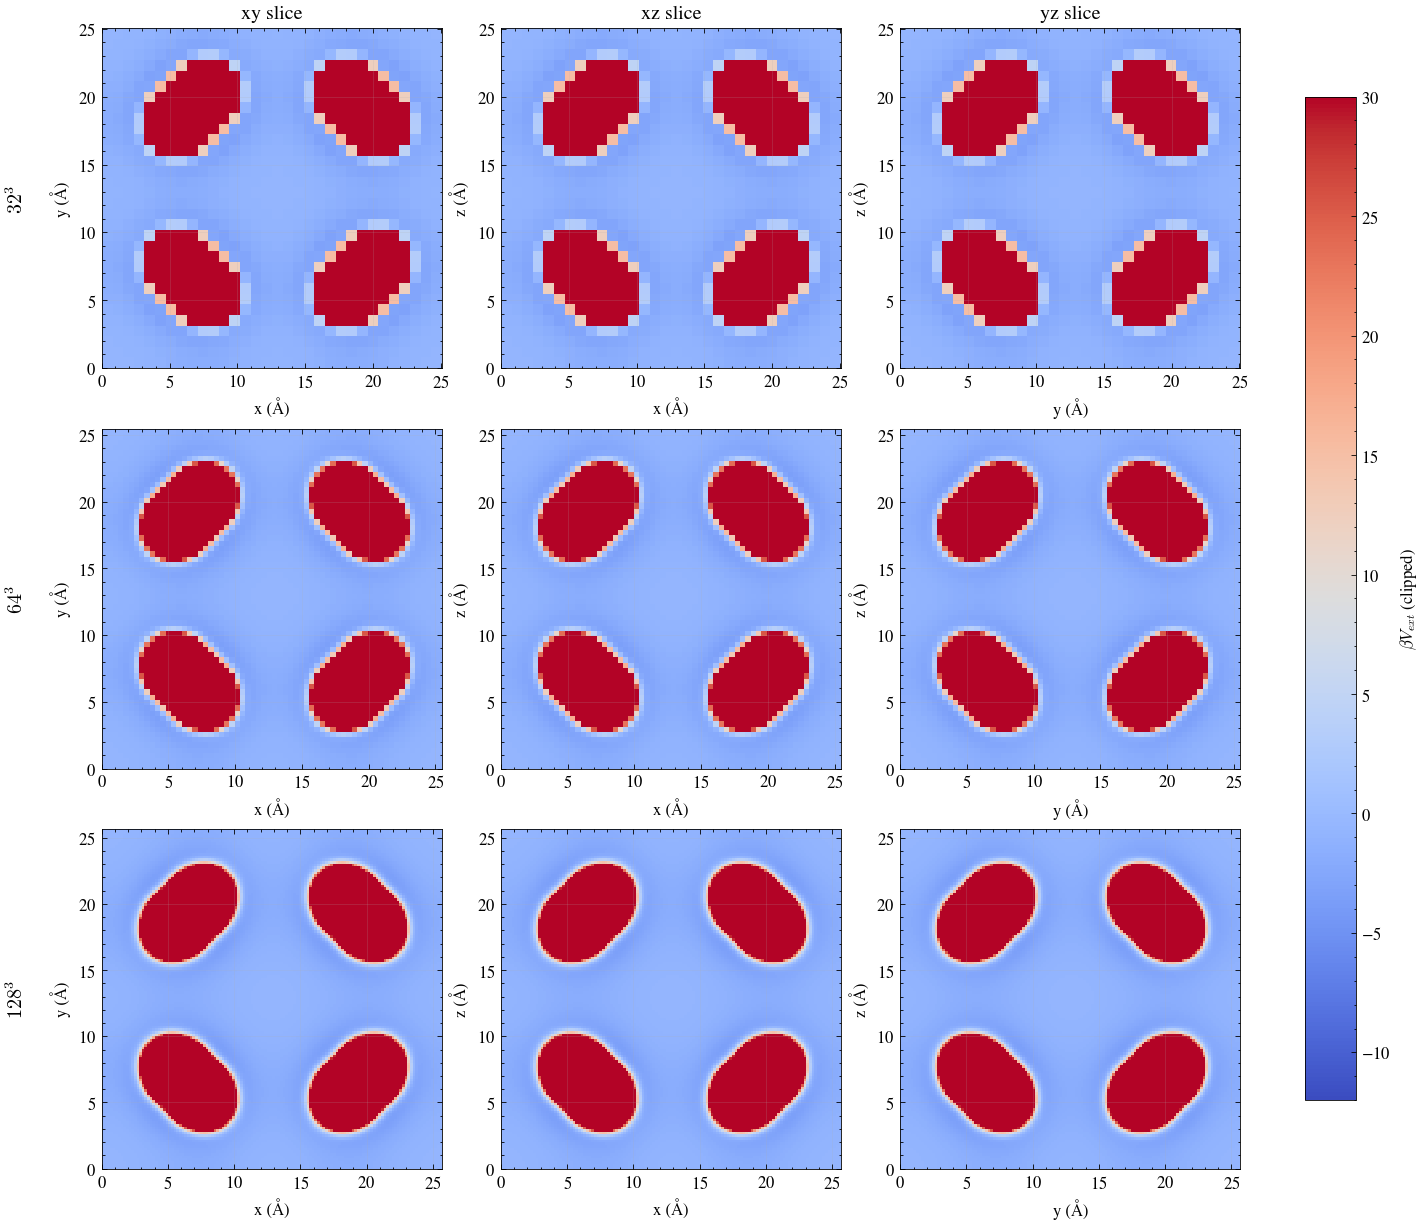

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(11.8, 10.2), constrained_layout=True)
planos = ["xy slice", "xz slice", "yz slice"]

for linha, N in enumerate([32, 64, 128]):
    g = campos[N]
    campo = g["betaV"]
    i, j, k = [n//2 for n in campo.shape]
    cortes = [
        (campo[:, :, k].T, [g["x"].min(), g["x"].max(), g["y"].min(), g["y"].max()], "x (Å)", "y (Å)"),
        (campo[:, j, :].T, [g["x"].min(), g["x"].max(), g["z"].min(), g["z"].max()], "x (Å)", "z (Å)"),
        (campo[i, :, :].T, [g["y"].min(), g["y"].max(), g["z"].min(), g["z"].max()], "y (Å)", "z (Å)"),
    ]
    for coluna, (corte, extent, xlabel, ylabel) in enumerate(cortes):
        im = axes[linha, coluna].imshow(
            np.clip(corte, -12, 30), origin="lower", extent=extent,
            cmap="coolwarm", vmin=-12, vmax=30, interpolation="nearest", aspect="equal",
        )
        if linha == 0:
            axes[linha, coluna].set_title(planos[coluna])
        axes[linha, coluna].set(xlabel=xlabel, ylabel=ylabel)
    axes[linha, 0].annotate(fr"${N}^3$", (-0.25, 0.5), xycoords="axes fraction",
                            ha="center", va="center", rotation=90, fontsize=12)

fig.colorbar(im, ax=axes, label=r"$\beta V_{ext}$ (clipped)", shrink=0.88)
plt.savefig("v6_Vext_32_64_128.png", dpi=220, bbox_inches="tight")
plt.show()


We build an independent object with **28³ points**, using `dx=L/28` (with rounding protection). In the previous version, `dx=0.25*sigma` produced 28 points whose numerical period was 26.11 Å, whereas the CIF measures 25.86584 Å. The adjustment makes the FFT period coincide with the cell used by the minimum-image convention. This is a discretization correction; 28³ remains a classroom grid subject to a convergence study.

In [ ]:
# The FFT period must exactly match the CIF cell.
N_MOF = 28
L_mof = float(estrutura.cell.lengths()[0])
dx = float(np.nextafter(np.float32(L_mof/N_MOF), np.float32(np.inf)))
dft = DFT(functional="aWBI+MMFA", device=DEVICE)
dft.set_fluid_properties(sigma=sigma, epsilon=epsilon, mass=mass, cut_off=rcut)
dft.set_gridsize(gridsize=dx)
dft.set_geometry_from_ase(estrutura)
dft.calculate_external_potential_lj(forcefield_path=ff_path)
betaV = dft.Vext.detach().cpu().numpy().copy() / T
dft.set_temperature(kT=T)

print("DFT grid:", dft.Ngrid)
print(f"Spacing: {dft.delta[0]:.4f} Å")
print(f"He-accessible volume: {dft.Vpore:.2f} Å³/cell")
print(f"He void fraction: {dft.helium_fraction:.4f}")


Geometry defined from ASE atoms object:
Lx=25.87 A, Ly=25.87 A, Lz=25.87 A
Unit cell Volume = 17305.33 A³
Solid Mass = 6158.94 u
Solid Mass Density = 0.3559 u/A³
Grid defined!
Lgrid = (np.float64(25.86584), np.float64(25.86584), np.float64(25.86584))  A
X-axis = [ 0.0 , 25.86584 ] A
Y-axis = [ 0.0 , 25.86584 ] A
Z-axis = [ 0.0 , 25.86584 ] A
Number of gridpoints = (28, 28, 28)
delta =  [0.9237801 0.9237801 0.9237801]  A
Vol = 17305.325019903623  A³


/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:318: RuntimeWarning: overflow encountered in add
  Vext[:] += lj_potential(R,sigmasf,epsilonsf,self.rcut,shift_cutoff=self.shift_cutoff)
/usr/local/lib/python3.13/dist-packages/pydftlj/dft.py:323: RuntimeWarning: overflow encountered in add
  self.Vext_helium[:] += lj_potential(R,sigmasHe,epsilonsHe,self.rcut,shift_cutoff=self.shift_cutoff)


Grid DFT: (28, 28, 28)
Spacing: 0.9238 Å
He-accessible volume: 14004.96 Å³/cell
He void fraction: 0.8093


### 11.4 Molecular structure versus potential isosurface

The `.cube` file combines atoms and a 3D field. We show two values in separate cells so that you can change them without rebuilding the potential.

In [ ]:
arquivo_vext = f"Vext_CH4_IRMOF1_{FORCEFIELD}.cube"
with open(arquivo_vext, "w") as arq:
    write_cube(arq, estrutura, data=betaV)

def mostrar_cube(caminho, isoval, cor, opacidade=0.55):
    texto = Path(caminho).read_text(encoding="utf-8")
    v = py3Dmol.view(width=800, height=500)
    v.addModel(texto, "cube")
    v.setStyle({"stick": {"radius": 0.10}, "sphere": {"scale": 0.22}})
    v.addVolumetricData(texto, "cube", {
        "isoval": float(isoval), "color": cor, "opacity": opacidade,
    })
    v.zoomTo()
    return v


First isosurface: an attractive region with Vext/T = −2. Change only the isovalue to explore other levels without recalculating the field.

In [ ]:
# Attractive region: try -1, -2, or -4.
mostrar_cube(arquivo_vext, isoval=-2.0, cor="blue")


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Second isosurface: Vext/T = 10 highlights the repulsive boundary. Compare it with the molecular structure and the attractive surface.

In [ ]:
# Repulsive/excluded region: try 5, 10, or 20.
mostrar_cube(arquivo_vext, isoval=10.0, cor="red", opacidade=0.28)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 12. A 3D density profile

The pressure fixes the reservoir through the EOS. Anderson then solves the Euler–Lagrange equation. We interpret the field only if `converged=True`.

In [ ]:
p = 10.0 # bar
rho_b = float(dft.calculate_rho_from_pbar(np.array([p]))[0])
dft.set_bulk_density(rho_b)
dft.set_initial_condition(model="bulk")

opt = Optimizer.create(
    "anderson", dft, alpha=0.10, history_size=6,
    atol=1e-8, rtol=1e-4, max_iter=15000,
)
inicio = time.perf_counter()
erro, n_iter = opt.run()
tempo = time.perf_counter() - inicio

display(pd.DataFrame([{
    "Pressure (bar)": p, "Bulk density (molecules/Å³)": rho_b,
    "Iterations": n_iter, "Time (s)": tempo,
    "Error": erro, "Converged": opt.converged,
}]).style.format({"Bulk density (molecules/Å³)": "{:.4e}", "Time (s)": "{:.1f}", "Error": "{:.2e}"}))

if not opt.converged:
    raise RuntimeError(f"3D profile did not converge: {opt.stop_reason}")


,Pressure (bar),Bulk density (molecules/Å³),Iterations,Time (s),Error,Converged
0,10.000000,2.4529e-04,8,0.4,8.17e-01,True


We extract three density slices on a logarithmic scale. The color bar belongs only to these maps.

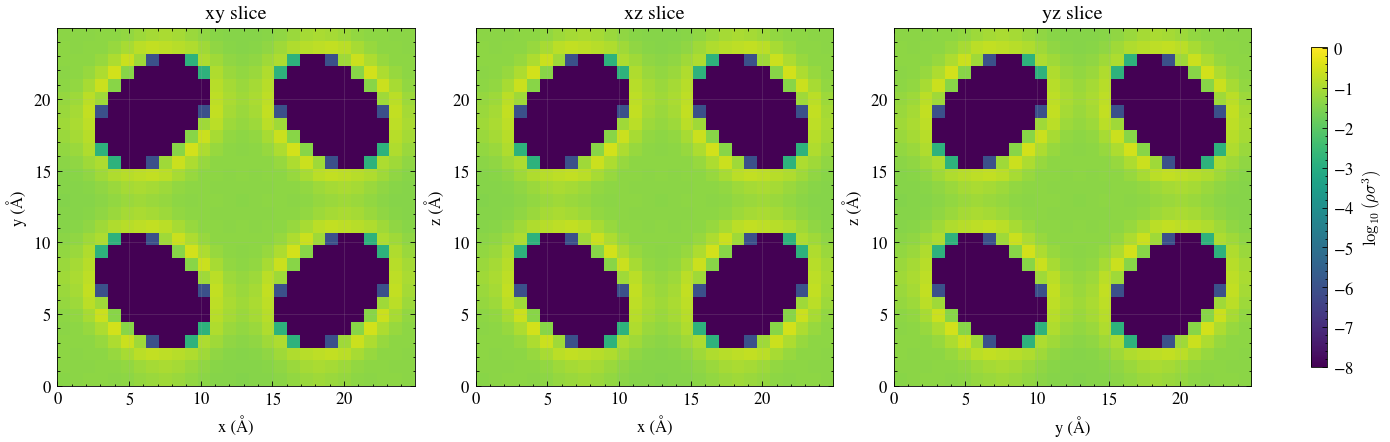

In [ ]:
rho_3d = dft.rho.detach().cpu().numpy()
rho_star = rho_3d * sigma**3
i, j, k = [n//2 for n in rho_3d.shape]
logrho = np.log10(np.maximum(rho_star, 1e-10))
vmax = float(np.quantile(logrho[dft.allowed.cpu().numpy()], 0.995))

fig, ax = plt.subplots(1, 3, figsize=(11.6, 3.7), constrained_layout=True)
cortes = [
    (logrho[:, :, k].T, [dft.x.min(), dft.x.max(), dft.y.min(), dft.y.max()], "xy", "x (Å)", "y (Å)"),
    (logrho[:, j, :].T, [dft.x.min(), dft.x.max(), dft.z.min(), dft.z.max()], "xz", "x (Å)", "z (Å)"),
    (logrho[i, :, :].T, [dft.y.min(), dft.y.max(), dft.z.min(), dft.z.max()], "yz", "y (Å)", "z (Å)"),
]
for eixo, (corte, extent, plano, xlabel, ylabel) in zip(ax, cortes):
    im = eixo.imshow(corte, origin="lower", extent=extent, cmap="viridis",
                     vmin=-8, vmax=vmax, interpolation="nearest", aspect="equal")
    eixo.set(title=f"{plano} slice", xlabel=xlabel, ylabel=ylabel)
fig.colorbar(im, ax=ax, label=r"$\log_{10}(\rho\sigma^3)$", shrink=0.85)
plt.savefig("v6_densidade_3D_cortes.png", dpi=220, bbox_inches="tight")
plt.show()


The average over the xy plane is an observable different from the slices. We plot it separately and compare it with the bulk.

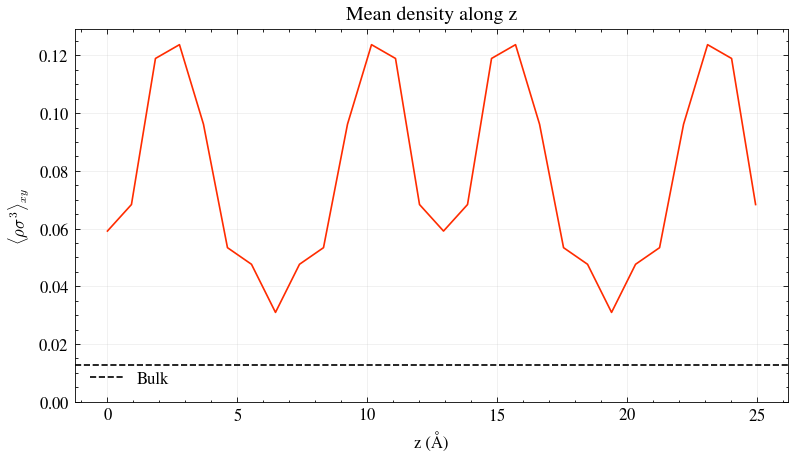

In [ ]:
# The xy average is an observable different from the slices, so it gets its own figure.
rho_media = rho_star.mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(6.6, 3.8), constrained_layout=True)
ax.plot(dft.z, rho_media, color="C3")
ax.axhline(rho_b*sigma**3, color="k", ls="--", label="Bulk")
ax.set(xlabel="z (Å)", ylabel=r"$\langle\rho\sigma^3\rangle_{xy}$",
       title="Mean density along z", ylim=(0, None))
ax.legend(frameon=False)
plt.show()


### 12.1 Isodensity at two levels

A low isosurface shows diffuse regions and connectivity; a high one highlights only the most occupied sites.

In [ ]:
arquivo_rho = f"rho_CH4_IRMOF1_{p:g}bar.cube"
with open(arquivo_rho, "w") as arq:
    write_cube(arq, estrutura, data=rho_3d)

rho_pos = rho_3d[(rho_3d > 1e-12) & np.isfinite(rho_3d)]
iso_baixa, iso_alta = np.quantile(rho_pos, [0.75, 0.95])
print(f"Isovalues: low={iso_baixa:.4g}; high={iso_alta:.4g} molecules/Å³")


Isovalues: low=0.003616; high=0.009587 molecules/Å³


A low isodensity value reveals diffuse regions and possible connections between cavities.

In [ ]:
mostrar_cube(arquivo_rho, isoval=iso_baixa, cor="cyan", opacidade=0.45)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

A higher value emphasizes only the most occupied sites. The density was not recalculated; only the surface level changed.

In [ ]:
mostrar_cube(arquivo_rho, isoval=iso_alta, cor="orange", opacidade=0.60)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 13. Adsorption isotherm up to 900 bar

We use **all 44 original points, from 0.001 to 900 bar**, without truncating the curve at 100 bar. To control the solver and inspect each point, we write the continuation loop explicitly using the repository `DFT` and `Optimizer` classes.

The converged density is the guess for the next pressure; the **Anderson history is new at every pressure**. We start with `alpha=0.10`, `regularization=1e-6`. A failed attempt is discarded, and the next one restores the last valid state with smaller mixing. We do not pass a NaN profile to the next pressure.

The convenience routine `calculate_isotherm` remains demonstrated in the grid study in section 14. The explicit loop is useful when you need to tune settings, interrupt failures, and export diagnostics without interpreting rounded logs.

$$N_{abs}=\int\rho(\mathbf r)d\mathbf r,\qquad N_{exc}=N_{abs}-\rho_b V_{pore}^{He}.$$

**Physical limitation:** reaching 900 bar with a converged residual does not prove grid independence or quantitative validity of the model in that range. The MIC/cutoff convention for the MOF remains as described in section 11.

In [ ]:
# Restore the smaller steps used in the original notebook for pressure continuation.
pressoes = np.r_[
    [0.001, 0.01],
    np.arange(0.1, 1.0, 0.1),
    np.arange(1.0, 10.0, 1.0),
    np.arange(10.0, 100.0, 10.0),
    np.arange(100.0, 200.0, 20.0),
    np.arange(250.0, 500.0, 50.0),
    np.arange(500.0, 1000.0, 100.0),
]
P_MAX_MOF = 900.0  # The main pathway includes the full range.
pressoes = pressoes[pressoes <= P_MAX_MOF]
exportar = [p for p in [10.0, 100.0] if p <= P_MAX_MOF]
nome_iso = f"isoterma_CH4_IRMOF1_300K_{FORCEFIELD}"
print(f"{len(pressoes)} pressures between {pressoes[0]:g} and {pressoes[-1]:g} bar")


44 pressures between 0.001 and 900 bar


We traverse the pressures in increasing order. The diagnostic table records the error without intermediate rounding, the total number of iterations, and the mixing value that converged. We store observables only after convergence.

In [ ]:
linhas_iso, linhas_diag = [], []
rhos_mof = dft.calculate_rho_from_pbar(pressoes)
inicio = time.perf_counter()
for j, (pressao_mof, rb_mof) in enumerate(zip(pressoes, rhos_mof)):
    dft.set_bulk_density(float(rb_mof))
    if j == 0:
        dft.set_initial_condition("bulk")
    ultimo_estado = dft.state.detach().clone()
    iter_total = 0
    for mistura in [0.10, 0.05, 0.01]:
        with torch.no_grad():
            dft.state.copy_(ultimo_estado)
        dft.apply_update()
        opt_mof = Optimizer.create("anderson", dft, alpha=mistura, history_size=6,
                                   regularization=1e-6, start_iteration=2,
                                   atol=1e-8, rtol=1e-4, max_iter=3000)
        opt_mof.run()
        iter_total += opt_mof.Niter
        if opt_mof.converged:
            break
    if not opt_mof.converged:
        raise RuntimeError(f"MOF: P={pressao_mof:g} bar; {opt_mof.stop_reason}. "
                           "Invalid state discarded: review the grid, pressure steps, and solver.")
    nabs_mof = float(dft.Nabs)
    nexc_mof = nabs_mof-float(rb_mof)*float(dft.Vpore)
    linhas_iso.append([pressao_mof, rb_mof, nabs_mof, nexc_mof,
                       1000*nabs_mof/float(dft.mss), 1000*nexc_mof/float(dft.mss)])
    linhas_diag.append([pressao_mof, iter_total, opt_mof.error, mistura, opt_mof.converged])
    if np.any(np.isclose(pressao_mof, exportar)):
        caminho = f"density_profile_{nome_iso}_P={pressao_mof:.2f}bar.cube"
        with open(caminho, "w") as arq:
            write_cube(arq, estrutura, data=dft.rho.detach().cpu().numpy())
    if (j+1) % 10 == 0 or j == len(pressoes)-1:
        print(f"MOF: {j+1}/{len(pressoes)} · {pressao_mof:g} bar · error={opt_mof.error:.3g}", flush=True)

iso = pd.DataFrame(linhas_iso, columns=["Pressure (bar)", "Bulk Density (molecules/AA3)",
                   "Absolute adsorption (molecules/uc)", "Excess adsorption (molecules/uc)",
                   "Absolute adsorption (mol/kg)", "Excess adsorption (mol/kg)"])
diagnostico = pd.DataFrame(linhas_diag, columns=["Pressure (bar)", "Iterations", "Error", "Alpha", "Converged"])
iso.to_csv(f"{nome_iso}.dat", index=False)
diagnostico.to_csv(f"{nome_iso}_diagnostico.csv", index=False)
print(f"Isotherm up to {iso['Pressure (bar)'].max():g} bar in {time.perf_counter()-inicio:.1f} s")


MOF: 10/44 · 0.8 bar · erro=0.252
MOF: 20/44 · 9 bar · erro=0.689
MOF: 30/44 · 100 bar · erro=0.839
MOF: 40/44 · 500 bar · erro=0.88
MOF: 44/44 · 900 bar · erro=0.759
Isotherm up to 900 bar em 4.5 s


The first table shows convergence at each pressure; the second contains absolute and excess adsorption. The final check requires all requested points and an error below 1, including 900 bar.

In [ ]:
assert len(iso) == len(pressoes) and np.isclose(iso["Pressure (bar)"].iloc[-1], P_MAX_MOF)
assert diagnostico["Converged"].all() and (diagnostico["Error"] < 1).all()
assert np.isfinite(iso.to_numpy()).all()
display(diagnostico.style.format({"Pressure (bar)": "{:.4g}", "Error": "{:.3e}", "Alpha": "{:.2f}"}))
colunas = ["Pressure (bar)", "Bulk Density (molecules/AA3)",
           "Absolute adsorption (mol/kg)", "Excess adsorption (mol/kg)"]
display(iso[colunas].style.format(precision=5))


,Pressure (bar),Iterations,Error,Alpha,Converged
0,0.001,3,1.103e-02,0.10,True
1,0.01,3,9.794e-02,0.10,True
2,0.1,9,4.229e-02,0.10,True
3,0.2,3,7.894e-01,0.10,True
4,0.3,3,3.539e-01,0.10,True
5,0.4,3,1.948e-01,0.10,True
6,0.5,3,8.221e-02,0.10,True
7,0.6,3,2.322e-01,0.10,True
8,0.7,3,1.446e-01,0.10,True
9,0.8,3,2.518e-01,0.10,True


,Pressure (bar),Bulk Density (molecules/AA3),Absolute adsorption (mol/kg),Excess adsorption (mol/kg)
0,0.00100,0.00000,0.00043,0.00038
1,0.01000,0.00000,0.00434,0.00379
2,0.10000,0.00000,0.04342,0.03793
3,0.20000,0.00000,0.08690,0.07591
4,0.30000,0.00001,0.13035,0.11387
5,0.40000,0.00001,0.17379,0.15181
6,0.50000,0.00001,0.21730,0.18983
7,0.60000,0.00001,0.26089,0.22792
8,0.70000,0.00002,0.30432,0.26585
9,0.80000,0.00002,0.34784,0.30386


We compare absolute and excess adsorption with the available data while keeping units and conventions consistent.

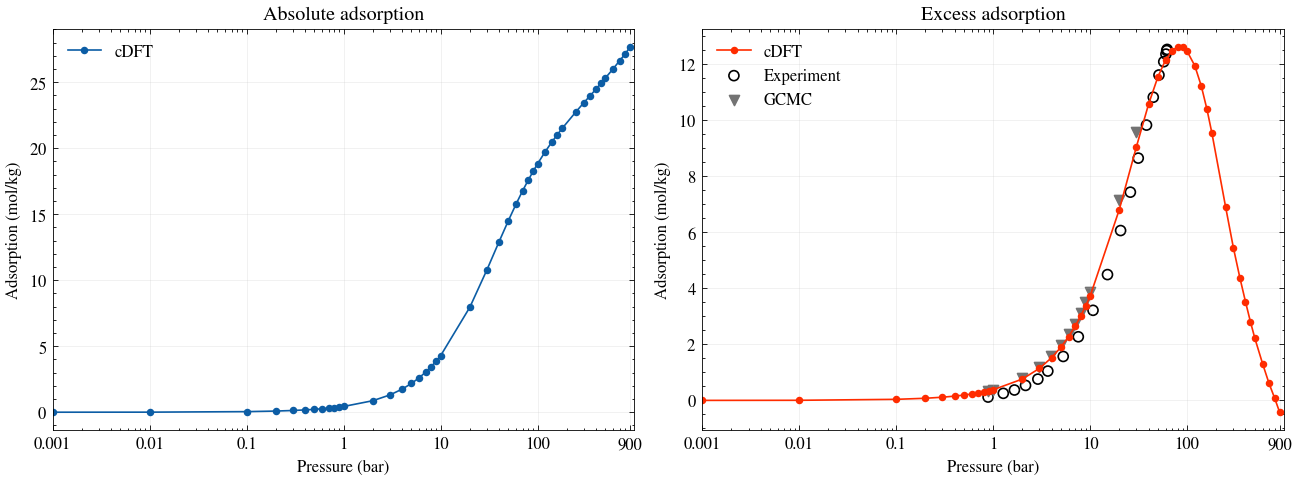

In [ ]:
zhou = pd.read_excel(dados / "H2andCH4-MOFandZIF-isotherm-Zhou2007.xls", sheet_name="CH4-MOF5")
keskin = pd.read_excel(dados / "CH4-MOF-isotherm-Keskin2016.xls", sheet_name="IRMOF-1")

# Zhou reports mass percent; convert it to mol/kg of adsorbent.
w = zhou["Nexc(%wt)-300K"] / 100
zhou_molkg = (1000/mass) * w/(1-w)

fig, ax = plt.subplots(1, 2, figsize=(10.8, 4.0), sharex=True, constrained_layout=True)
ax[0].plot(iso["Pressure (bar)"], iso["Absolute adsorption (mol/kg)"],
           "o-", ms=3.5, color="C0", label="cDFT")
ax[1].plot(iso["Pressure (bar)"], iso["Excess adsorption (mol/kg)"],
           "o-", ms=3.5, color="C3", label="cDFT")
ax[1].scatter(zhou["Pexc(bar)-300K"], zhou_molkg,
              facecolors="none", edgecolors="k", label="Experiment")
ax[1].scatter(keskin["Pressure (bar)"], keskin["Excess adsorption (mmol/g)"],
              marker="v", color="0.45", label="GCMC")

for eixo in ax:
    eixo.set_xscale("log")
    eixo.set_xlim(pressoes[0], P_MAX_MOF*1.1)
    eixo.set_xticks([0.001, 0.01, 0.1, 1, 10, 100, 900],
                    labels=["0.001", "0.01", "0.1", "1", "10", "100", "900"])
    eixo.set(xlabel="Pressure (bar)", ylabel="Adsorption (mol/kg)")
    eixo.legend(frameon=False)
ax[0].set_title("Absolute adsorption")
ax[1].set_title("Excess adsorption")
plt.savefig("v6_isoterma_CH4_IRMOF1.png", dpi=220, bbox_inches="tight")
plt.show()


The fields at the selected pressures have already been exported. We list the files so that you can open them in the viewer or reuse them.

In [ ]:
# The requested profiles were exported; we will not repeat them in new plots.
for arquivo in sorted(Path(".").glob(f"density_profile_{nome_iso}_*.cube")):
    print(arquivo)


density_profile_isoterma_CH4_IRMOF1_300K_DREIDING_P=10.00bar.cube
density_profile_isoterma_CH4_IRMOF1_300K_DREIDING_P=100.00bar.cube


# Part E — Physical and numerical extensions

## 14. Extension: MOF profiles and isotherms on three grids

We now refine more than the rendering of Vext: we solve cDFT on **32³, 64³, and 128³** grids with the same CIF, force field, temperature, and pressures. The cost grows substantially; run this block outside the core pathway if necessary.

**Scope of the comparison:** 0.001–10 bar. In local tests, the 32³ grid became unstable from 20 bar onward with the settings tested, even with smaller mixing. The broad isotherm above remains on the 28³ classroom grid with a period adjusted to the CIF. Do not extrapolate grid-independence conclusions to 900 bar. Lack of solver convergence is not evidence of a physical transition.

The code captures the logs without printing every pressure. It then checks convergence and stores the final profile at 10 bar. A single table summarizes cost and resolution; complete data remain in files.

In [ ]:
p_malha = np.geomspace(0.001, 10.0, 12)  # Same pressures on all three grids.
malhas = {}
custos = []
for N in [32, 64, 128]:
    inicio = time.perf_counter()
    log = StringIO()
    with redirect_stdout(log):
        grade = DFT(functional="aWBI+MMFA", device=DEVICE)
        grade.set_fluid_properties(sigma=3.73, epsilon=148.0, mass=16.043, cut_off=14.0)
        # nextafter avoids obtaining N+1 through rounding when defining the step.
        dx = np.nextafter(np.float32(estrutura.cell.lengths()[0]/N), np.float32(np.inf))
        grade.set_gridsize(float(dx))
        grade.set_geometry_from_ase(estrutura)
        with np.errstate(over="ignore"):  # +inf in the LJ core will be treated as a forbidden region.
            grade.calculate_external_potential_lj(forcefield_path=dados / f"{FORCEFIELD}-forcefield.dat")
        grade.set_temperature(300.0)
        nome = f"v6_malha_{N}"
        grade.calculate_isotherm(p_malha, filename=nome)
    Path(nome + ".log").write_text(log.getvalue(), encoding="utf-8")
    # The helper prints pressure, bulk, Nabs, iterations, and normalized error.
    estados = []
    for linha in log.getvalue().splitlines():
        campos = linha.split()
        if len(campos) == 5:
            try: estados.append([float(x) for x in campos])
            except ValueError: pass
    erros = np.asarray(estados)[:, -1] if estados else np.array([])
    if "Warning: convergence failed" in log.getvalue() or len(erros) != len(p_malha) or not np.isfinite(erros).all() or (erros > 1).any():
        raise RuntimeError(f"Grid {N}³: inspect {nome}.log before comparing results.")
    iso = pd.read_csv(nome + ".dat")
    rho = grade.rho.detach().cpu().numpy()
    malhas[N] = {"Iso": iso, "Rho": rho, "L": grade.Lgrid,
                 "Z": grade.Z[0, 0, :].copy(), "Rhob": grade.rhob}
    custos.append([N, float(grade.delta[0]), time.perf_counter()-inicio, float(grade.Nabs)])
    del grade
    gc.collect()
    if DEVICE == "cuda": torch.cuda.empty_cache()

display(pd.DataFrame(custos, columns=["N", "Step (Å)", "Total time (s)", "Nabs at 10 bar"]))


,N,Step (Å),Total time (s),Nabs at 10 bar
0,32,0.808308,2.175252,26.622459
1,64,0.404154,6.719196,26.296618
2,128,0.202077,68.697193,26.259630


### 14.1 The same density slices at 10 bar

Each row is a grid and each column is a plane. We use the same limits and logarithmic scale without visual interpolation. Refinement that only smooths a boundary is not enough: also compare integrals and isotherms.

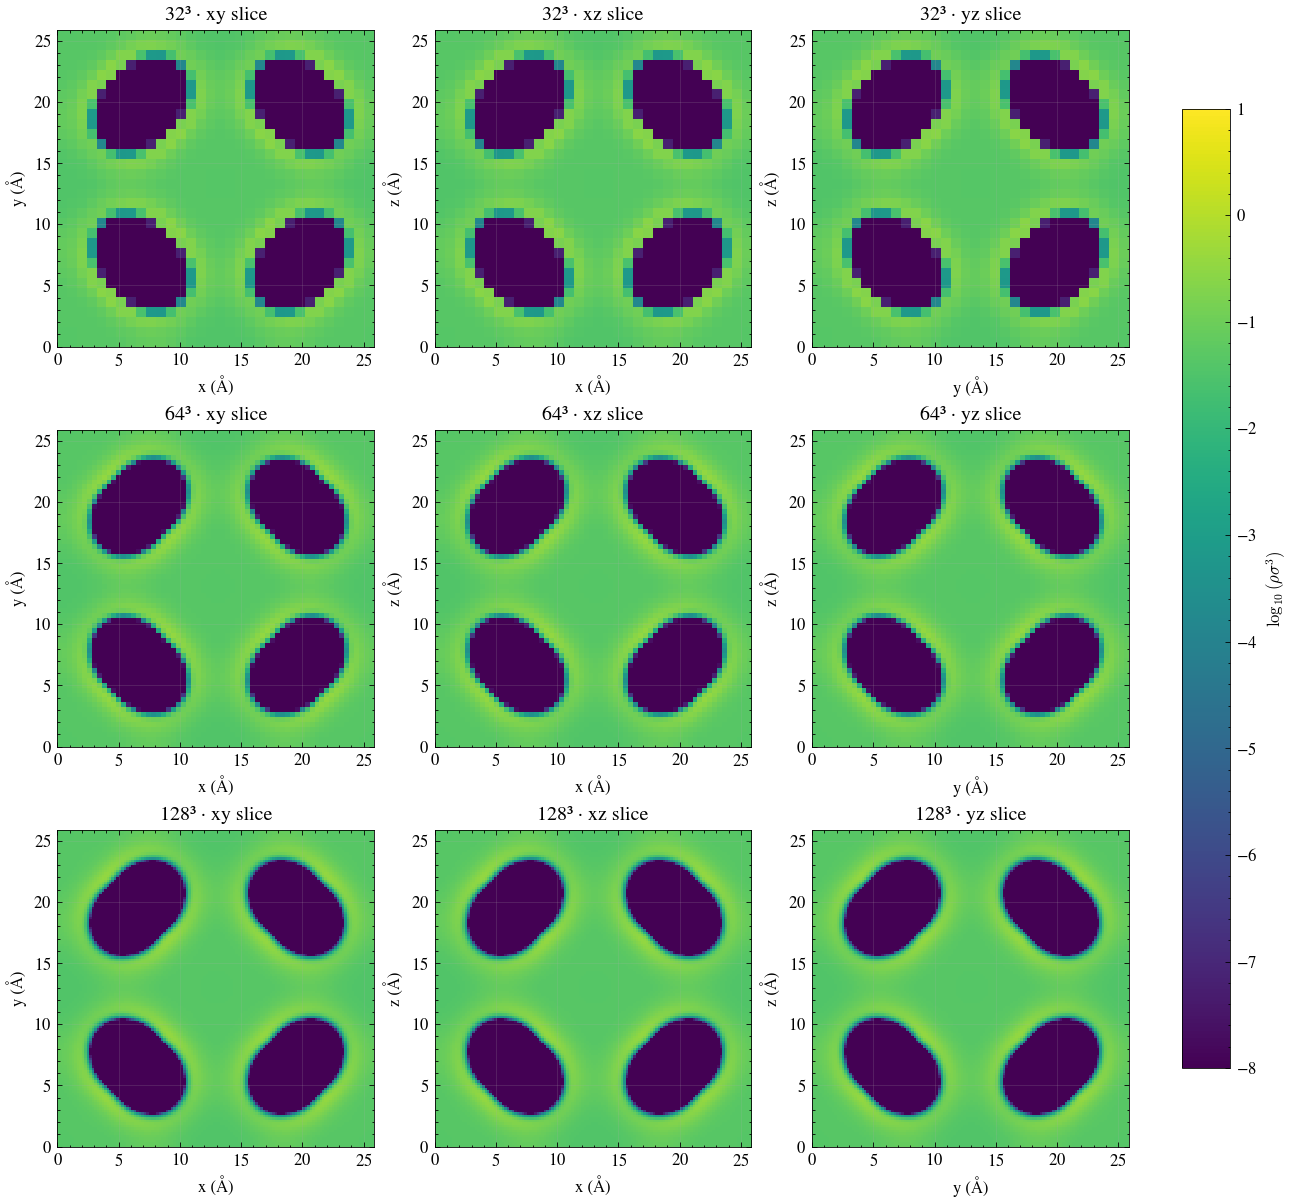

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(10.8, 10), constrained_layout=True)
for linha, (N, resultado) in enumerate(malhas.items()):
    rho = resultado["Rho"] * 3.73**3
    L = resultado["L"]
    cortes = [rho[:, :, N//2], rho[:, N//2, :], rho[N//2, :, :]]
    for coluna, (corte, plano, i, j) in enumerate(zip(cortes, ["xy", "xz", "yz"], [0,0,1], [1,2,2])):
        mapa = ax[linha, coluna].imshow(np.log10(np.maximum(corte.T, 1e-8)),
            origin="lower", extent=(0, L[i], 0, L[j]), vmin=-8, vmax=1,
            cmap="viridis", interpolation="nearest")
        ax[linha, coluna].set(title=f"{N}³ · {plano} slice", xlabel=f"{plano[0]} (Å)", ylabel=f"{plano[1]} (Å)")
fig.colorbar(mapa, ax=ax, label=r"$\log_{10}(\rho\sigma^3)$", shrink=0.85)
plt.show()


The average over the xy plane appears in its own figure. The isotherms use three panels with common limits; the dashed 128³ curve is a numerical reference, not an exact solution.

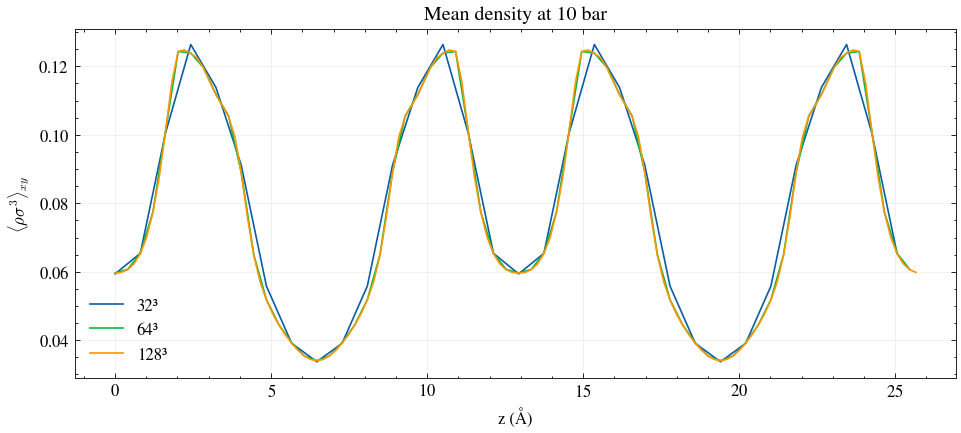

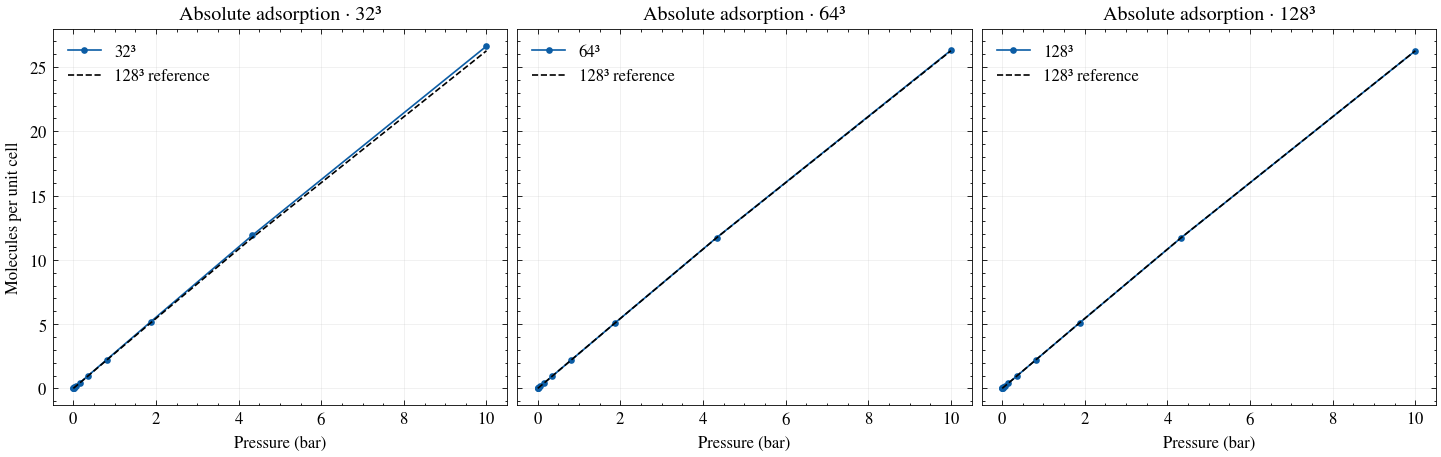

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.6), constrained_layout=True)
for N, resultado in malhas.items():
    ax.plot(resultado["Z"], resultado["Rho"].mean(axis=(0,1))*3.73**3, label=f"{N}³")
ax.set(xlabel="z (Å)", ylabel=r"$\langle\rho\sigma^3\rangle_{xy}$", title="Mean density at 10 bar")
ax.legend(frameon=False)
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True, constrained_layout=True)
ref = malhas[128]["Iso"]
for eixo, (N, resultado) in zip(ax, malhas.items()):
    iso = resultado["Iso"]
    eixo.plot(iso["Pressure (bar)"], iso["Absolute adsorption (molecules/uc)"], "o-", ms=3, label=f"{N}³")
    eixo.plot(ref["Pressure (bar)"], ref["Absolute adsorption (molecules/uc)"], "k--", lw=1, label="128³ reference")
    eixo.set(xlabel="Pressure (bar)", title=f"Absolute adsorption · {N}³")
    eixo.legend(frameon=False)
ax[0].set_ylabel("Molecules per unit cell")
plt.show()


### Exercise 3: CH₄ adsorption in amorphous carbon at 200 K

#### Objective
Calculate methane adsorption in a three-dimensional atomistic amorphous-carbon structure, relating the heterogeneity of the external potential to the spatial distribution of the fluid and to the isotherms.

Use the CIF **`aCarbon-Bhatia-id001.cif`** available in the repository. Follow [Example6–Adsorption3D_CH4_on_aCarbon_Bathia](https://github.com/elvissoares/PyDFTlj/blob/16e7d4349e22d3ead8774a332011b4c3d21806cd/examples/Example6-Adsorption3D_CH4_on_aCarbon_Bathia.ipynb), while keeping the temperature of this exercise at **200 K**.

From the structure and results:

1. **Characterize the adsorbent:** Read the CIF with ASE, verify cell dimensions and angles, visualize the structure, and report the He-probe accessible volume and its void fraction.
2. **Build the external potential:** Apply the solid–fluid parameters and plot Vext/T slices in the xy, xz, and yz planes. Explain why this field cannot be replaced directly by a Steele slit with a single width.
3. **Calculate the isotherm:** Solve cDFT by continuation between 0.001 and 100 bar. Plot absolute and excess adsorption in molecules/unit cell and convert to mol/kg of adsorbent.
4. **Interpret pore occupancy:** Compare density slices at 0.01, 1, and 100 bar using a common color scale, relating the sites occupied first to the external field. Export at least one `.cube` field.
5. **Assess calculation quality:** Record the functional, grid, cutoff, device, tolerances, and convergence. Distinguish solver convergence from grid independence and physical validation.

---

#### Parameters and conditions

| Choice | Value / guidance |
|---|---|
| Fluid | TraPPE-UA CH₄: σ=3.73 Å; ε/kB=148 K; mass=16.043 u |
| Solid | `aCarbon-Bhatia-id001.cif`; carbon parameters from `DREIDING-forcefield.dat` |
| Cross interactions | Lorentz–Berthelot, as in the package helper |
| Temperature | 200 K |
| Answer-key functional | `aRF+MMFA`; state the difference from `aWBI+MMFA` in the original example |
| Initial grid | `gridsize=0.25*sigma`; verify the returned number of nodes |
| Pressures | 41 logarithmic points from 0.001 to 100 bar |
| Excess adsorption | $N_{exc}=N_{abs}-\rho_b V_{pore}^{He}$, with He at the same temperature |

#### Suggested procedure

- Follow the workflow structure → external field → temperature → reservoir → guess → solver.
- Use an object independent of the MOF object so that its results are not overwritten.
- Reuse the converged density as pressure increases and stop the analysis if a nonconverged state appears.
- Keep identical limits and color scales when comparing density maps.
- Discuss how tortuosity and the distribution of local environments distinguish this material from an idealized slit pore.

**Caution regarding the reference:** Example6 and its GCMC file are at **300 K**, not 200 K. Do not overlay these data on the 200 K isotherm as if they were a validation. A quantitative comparison requires matching temperature, functional, cutoffs, structure, and other conventions.

#### References

- Structure and procedure: [PyDFTlj — Example6](https://github.com/elvissoares/PyDFTlj/blob/16e7d4349e22d3ead8774a332011b4c3d21806cd/examples/Example6-Adsorption3D_CH4_on_aCarbon_Bathia.ipynb).
- TraPPE-UA CH₄: Martin & Siepmann (1998), [DOI](https://doi.org/10.1021/jp972543+).
- DREIDING: Mayo, Olafson & Goddard (1990), [DOI](https://doi.org/10.1021/j100389a010).

In [ ]:
# Exercise 3 resolution





## 15. Extension: Lennard–Jones RDF by the test-particle method

A different application of the same machinery: we fix an LJ particle at the center of the box and use its interaction as an external potential. In the homogeneous fluid,

$$V_{ext}(r)=u_{LJ}(r),\qquad g(r)=\rho(r)/\rho_b.$$

We do not calculate the RDF from trajectories. We solve the equilibrium response to the field of one particle. This procedure is approximate when the functional is approximate.

We reproduce the first state from [Example4–RadialDistributionFunction](https://github.com/elvissoares/PyDFTlj/blob/16e7d4349e22d3ead8774a332011b4c3d21806cd/examples/Example4-RadialDistributionFunction.ipynb): $T^*=2.934$ and $\rho_b^*=0.450$, with WBI+MFA, WBI+WDA, and WBI+MMFA. The points are from **molecular dynamics (MD)** by [Verlet (1968)](https://doi.org/10.1103/PhysRev.165.201), as stated in the original example—even though they reside in the `MC` folder.

We use a $12\sigma$ box, a $5\sigma$ cutoff, and a 64³ grid for initial exploration. To approach the resolution of the original example (step $0.1\sigma$), use N=128 and recheck convergence. The file also contains the state $T^*=2.888$, $\rho_b^*=0.850$; we leave it for exploration as an exercise, not as a case already validated in this section.

**Numerical correction in this revision:** the error `RDF MMFA: Non-finite energy or residual` was reproduced with Picard. We use ABC-FIRE for all three functionals, following the strategy in the original example and now using the `Optimizer.create` API. In the CPU test, all three solutions converged on the 64³ grid with the tolerances below, without changing the package equations. Convergence on one grid does not replace a resolution check.

In [ ]:
N = 64
T_rdf, rho_rdf = 2.934, 0.450  # Reduced units: sigma = epsilon = 1.
arquivo_rdf = dados / "MCdata-radialdistribution-lennardjones-Verlet1968.xls"
if not arquivo_rdf.exists():
    urlretrieve(f"{RAW}/examples/data/MC/{arquivo_rdf.name}", arquivo_rdf)
md_rdf = pd.read_excel(arquivo_rdf, sheet_name=f"rhob={rho_rdf:.3f}")
perfis_rdf, resumo_rdf = {}, []
for modelo in ["MFA", "WDA", "MMFA"]:
    with redirect_stdout(StringIO()):
        s = DFT(functional="WBI+"+modelo, device=DEVICE)
        s.set_fluid_properties(sigma=1.0, epsilon=1.0, mass=1.0, cut_off=5.0)
        s.set_gridsize(12.0/N)
        s.set_geometry(lengths=(12.0, 12.0, 12.0))
        s._from_ase = False
    R = np.sqrt((s.X-6)**2 + (s.Y-6)**2 + (s.Z-6)**2)
    r = np.maximum(R, 0.5)  # Avoid division by zero in the already inaccessible core.
    V = np.where(R < 5, 4*(r**-12-r**-6), 0.0)
    s.set_external_potential(V)
    s.set_temperature(T_rdf)
    s.set_bulk_density(rho_rdf)
    s.set_initial_condition("bulk")
    # ABC-FIRE: strategy from the original example, using the current API.
    # Picard in the previous version produced NaN for MMFA at this same state.
    opt = Optimizer.create("fire", s, mode="abc-fire", alpha=0.15,
                           dt=0.01, dt_max=0.10,
                           atol=1e-7, rtol=1e-4, max_iter=2500)
    if DEVICE == "cuda": torch.cuda.synchronize()
    inicio = time.perf_counter()
    opt.run()
    if DEVICE == "cuda": torch.cuda.synchronize()
    resumo_rdf.append([modelo, opt.Niter, opt.error, opt.converged, time.perf_counter()-inicio])
    if not opt.converged:
        raise RuntimeError(f"RDF {modelo}: {opt.stop_reason}; error={opt.error:.3e}")
    print(f"RDF {modelo}: {opt.Niter} iterations; error={opt.error:.3g}", flush=True)
    # A radial slice reproduces the extraction used in the original example (without bin broadening of peaks).
    x = np.squeeze(s.X[:, N//2, N//2]) - 6
    g = s.rho[:, N//2, N//2].detach().cpu().numpy()/rho_rdf
    perfis_rdf[modelo] = (x[x >= 0], g[x >= 0])

display(pd.DataFrame(resumo_rdf, columns=["Model", "Iterations", "Error", "Converged", "Time (s)"]))


RDF MFA: 83 iterations; erro=0.996
RDF WDA: 71 iterations; erro=0.629
RDF MMFA: 71 iterations; erro=0.668


,Model,Iterations,Error,Converged,Time (s)
0,MFA,83,0.996153,True,0.467785
1,WDA,71,0.628868,True,0.723367
2,MMFA,71,0.668479,True,0.732428


We compare $g(r)$ with MD and with the limit $g(r)	o1$ far from the fixed particle. Peak position, height, and damping are more informative than a single aggregate error. Remaining differences include the functional approximation, resolution, cutoff, and conditions of the reference data.

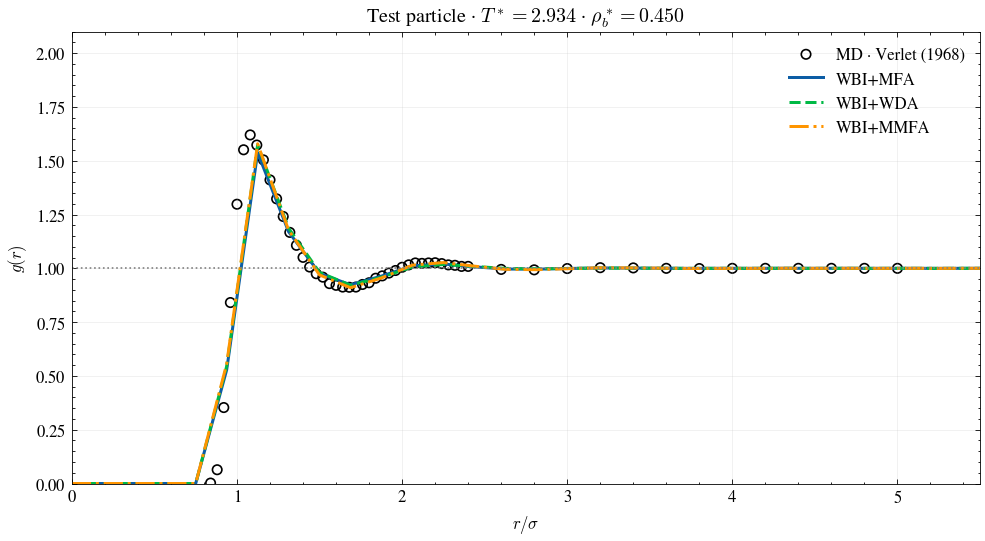

In [ ]:
fig, ax = plt.subplots(figsize=(8.2, 4.5), constrained_layout=True)
ax.scatter(md_rdf["r"], md_rdf[f"KT={T_rdf:.3f}"], facecolors="none", edgecolors="k", s=32, label="MD · Verlet (1968)")
for (modelo, (r, g)), estilo in zip(perfis_rdf.items(), ["-", "--", "-."]):
    ax.plot(r, g, estilo, lw=1.8, label="WBI+"+modelo)
ax.axhline(1, color="0.5", ls=":", lw=1)
ax.set(xlim=(0, 5.5), ylim=(0, 2.1), xlabel=r"$r/\sigma$", ylabel=r"$g(r)$",
       title=fr"Test particle · $T^*={T_rdf:.3f}$ · $\rho_b^*={rho_rdf:.3f}$")
ax.legend(frameon=False)
plt.show()


# Part F — Troubleshooting and performance

## 16. Limitations and diagnostics

### 16.1 The model in this course does not include

- Mixtures, multisite molecules, or orientations;
- Charges, quadrupoles, or electrostatics;
- Association, hydrogen bonding, or solid flexibility;
- Nonorthogonal cells.

### 16.2 Common problems

| Symptom | Action |
|---|---|
| Old `Set_...` method or `ndim` argument | Use the v1.0.3 `snake_case` API |
| `float` without a `.round()` method | Do not use `get_fluid_density_information()`; format with `f"{float(x):.3f}"` |
| Solver oscillates | Reduce `alpha`, use continuation; compare methods in section 17 |
| MMFA RDF gives `NaN` with Picard | Use ABC-FIRE from section 15; do not accept the profile from the failed iteration |
| Slow 1D isotherm | Use the 1–3 bar range and continuation from section 9; monitor progress |
| `NaN` at $H<3\sigma$ | Treat as an advanced case; refine the strategy, not only `max_iter` |
| CUDA unavailable or out of memory | Use CPU or a smaller grid; measure the cost in section 18 |
| Empty py3Dmol view | Change the isovalue or use the Matplotlib slices |
| Isotherm converges but is unrealistic | Audit units, parameters, functional, cutoff, and excess-adsorption definition |

Numerical convergence is necessary; physical validation remains essential.

**Grid and pressure:** section 13 reaches 900 bar, but solver convergence does not guarantee grid independence over this range. The 32³/64³/128³ extension retains a separate low-pressure study.

**Overflow in the LJ core:** the atomistic sum in float32 may produce +∞ near solid atoms. `set_temperature` classifies these regions as forbidden. This is different from a NaN in the solver residual, which invalidates the result.

## 17. Optimizers: comparison on the 3D atomistic slab

We return to **the same 3D system from section 10**, at 300 K and 10 bar, and restore the bulk density before each method. Fluid, slab, field, grid, reservoir, and tolerances are identical. The cost of building the slab and Vext is outside the timer.

Picard now uses `alpha=0.20`. Anderson uses `alpha=0.10`, a history of six vectors, and regularization of $10^{-6}$. ABC-FIRE uses initial mixing 0.50 and steps of 0.05–0.10. The parameters were tuned for this case and are not universal recommendations.

$$\mathrm{Error}=\frac{1}{\sqrt N}\left\|\frac{R_i}{\mathrm{atol}+\mathrm{rtol}|\ln\rho_i|}\right\|_2<1.$$

The plots use **all recorded values, without smoothing or removing iterations**. A small rebound in the FIRE residual may occur because of its inertial dynamics; this differs from the large spikes/divergence in the previous comparison. The table also verifies that all three methods reach the same adsorbed amount.

In [ ]:
solver_3d = slab_dft
solver_3d.set_bulk_density(rho_res_c)
solver_3d.set_initial_condition("bulk")
estado_inicial = solver_3d.state.detach().clone()
solver_3d.update_system()  # Warm up the FFTs before timing the methods.


We solve exactly the same initial profile with all three optimizers. We store error, Ω, time, and iteration count for comparison.

In [ ]:
metodos = {
    "Picard": ("picard", {"alpha": 0.20}),
    "Anderson": ("anderson", {"alpha": 0.10, "history_size": 6, "regularization": 1e-6}),
    "ABC-FIRE": ("fire", {"mode": "abc-fire", "alpha": 0.50, "dt": 0.05, "dt_max": 0.10}),
}

resumo, historicos, energias = [], {}, {}
for nome, (algoritmo, parametros) in metodos.items():
    # Same initial condition for a fair comparison.
    with torch.no_grad():
        solver_3d.state.copy_(estado_inicial)
    solver_3d.apply_update()

    opt = Optimizer.create(
        algoritmo, solver_3d, **parametros,
        atol=1e-7, rtol=1e-4, max_iter=2000,
    )
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    inicio = time.perf_counter()
    erro, n_iter = opt.run()
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    tempo = time.perf_counter() - inicio

    resumo.append([nome, n_iter, tempo, erro, opt.converged, opt.stop_reason, float(solver_3d.Nabs)])
    historicos[nome] = opt.error_log.copy()
    energias[nome] = (np.asarray(opt.energy_log)/epsilon_c).tolist()

benchmark_solver = pd.DataFrame(
    resumo, columns=["Method", "Iterations", "Time (s)", "Final error", "Converged", "Reason", "Nabs"]
)
display(benchmark_solver.style.format({"Time (s)": "{:.3f}", "Final error": "{:.2e}"}))


,Method,Iterations,Time (s),Final error,Converged,Reason,Nabs
0,Picard,36,0.377,9.41e-01,True,Convergence criterion reached,29.723406
1,Anderson,9,0.326,3.51e-01,True,Convergence criterion reached,29.739162
2,ABC-FIRE,57,2.604,8.82e-01,True,Convergence criterion reached,29.723835


The plots show residual, Ω, and time. An energy plateau may appear before the residual satisfies the tolerance.

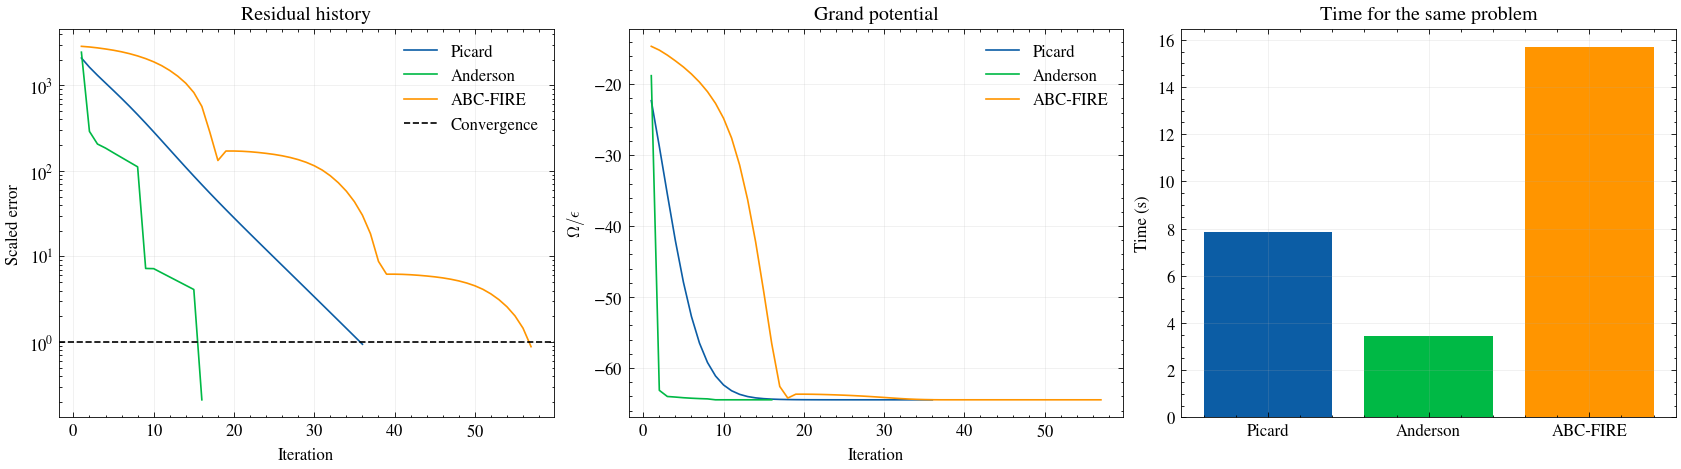

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14.0, 3.9), constrained_layout=True)
for nome, erros in historicos.items():
    it = np.arange(1, len(erros)+1)
    ax[0].semilogy(it, erros, label=nome)
    ax[1].plot(np.arange(1, len(energias[nome])+1), energias[nome], label=nome)
ax[0].axhline(1, color="k", ls="--", lw=1, label="Convergence")
ax[0].set(xlabel="Iteration", ylabel="Scaled error", title="Residual history")
ax[1].set(xlabel="Iteration", ylabel=r"$\Omega/\epsilon$", title="Grand potential")
for eixo in ax[:2]:
    eixo.legend(frameon=False)
ax[2].bar(benchmark_solver["Method"], benchmark_solver["Time (s)"], color=["C0", "C1", "C2"])
ax[2].set(ylabel="Time (s)", title="Time for the same problem")
for barra, convergiu in zip(ax[2].patches, benchmark_solver["Converged"]):
    if not convergiu:
        barra.set_hatch("//")
        ax[2].annotate("Failed", (barra.get_x()+barra.get_width()/2, barra.get_height()),
                       ha="center", va="bottom", fontsize=8)
plt.show()


## 18. CPU or GPU? Measure the change in scaling

**No GPU available?** All examples can be run on CPU; start with small grids and retain your results.

A short 1D FFT makes little use of a GPU. Kernel launches, synchronization, and transfers may cost more than the calculation; the solver also reads scalars on the CPU at every iteration. A GPU therefore need not outperform the previous example.

We now solve a **complete 3D cDFT problem** with a smooth periodic field on **32³, 64³, and 128³** grids, all included by default. Doubling N multiplies the number of points by eight. We use the same functional, state, guess, tolerance, and solver on both devices.

The smooth field facilitates convergence and isolates the cost of the convolutions. Setup and warm-up are outside the timer; three repetitions produce a median. The purpose is to observe behavior on the available hardware, not to guarantee a speedup in advance.

In [ ]:
def criar_benchmark_3d(N, device):
    s = DFT(functional="aWBI+MMFA", device=device)
    s.set_fluid_properties(sigma=1.0, epsilon=1.0, mass=1.0, cut_off=3.5)
    s.set_gridsize(8.0/N)
    s.set_geometry(lengths=(8.0, 8.0, 8.0))
    s._from_ase = False
    V = 0.1 * (np.cos(2*np.pi*s.X/8) + np.cos(2*np.pi*s.Y/8) + np.cos(2*np.pi*s.Z/8))
    s.set_external_potential(V)
    s.set_temperature(1.5)
    s.set_bulk_density(0.10)
    s.set_initial_condition("bulk")
    return s

print("PyTorch CPU threads:", torch.get_num_threads())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Unavailable")


Threads PyTorch na CPU: 1
GPU: Tesla T4


We time only the solution. Each repetition starts from the bulk. The convergence and Nabs checks avoid comparing timings for different solutions. This block is an extension and may take a few minutes on CPU.

In [ ]:
dispositivos = ["cpu"] + (["cuda"] if torch.cuda.is_available() else [])
registros = []
N_BENCH = [32, 64, 128]  # Full comparison, including on CPU.
for N in N_BENCH:
    for device in dispositivos:
        with redirect_stdout(StringIO()):
            s = criar_benchmark_3d(N, device)
        s.update_system()  # Warm up the FFTs before timing.
        for repeticao in range(3):
            s.set_initial_condition("bulk")
            opt = Optimizer.create("anderson", s, alpha=0.10, regularization=1e-6,
                                   atol=1e-7, rtol=1e-4, max_iter=2000)
            if device == "cuda": torch.cuda.synchronize()
            inicio = time.perf_counter()
            opt.run()
            if device == "cuda": torch.cuda.synchronize()
            registros.append([N, device, time.perf_counter()-inicio,
                              opt.Niter, opt.error, opt.converged, float(s.Nabs)])
        del opt, s
        gc.collect()
        if device == "cuda": torch.cuda.empty_cache()

bench = pd.DataFrame(registros, columns=["N", "Device", "Time (s)",
                                        "Iterations", "Error", "Converged", "Nabs"])
resumo_gpu = bench.groupby(["N", "Device"], as_index=False).agg(
    Tempo_s=("Time (s)", "median"), Iteracoes=("Iterations", "median"),
    Error=("Error", "max"), Converged=("Converged", "all"), Nabs=("Nabs", "median"))
display(resumo_gpu.style.format({"Tempo_s": "{:.3f}", "Error": "{:.2e}", "Nabs": "{:.5f}"}))

if "cuda" in dispositivos:
    nabs_por_device = resumo_gpu.pivot(index="N", columns="Device", values="Nabs")
    diferenca_nabs = abs(nabs_por_device["cpu"]-nabs_por_device["cuda"]) / abs(nabs_por_device["cpu"])
    print("Relative difference in Nabs (CPU/GPU):")
    display(diferenca_nabs.rename("Relative difference").to_frame())


,N,Device,Time_s,Iteracoes,Error,Converged,Nabs
0,32,cpu,0.252,9.000000,8.85e-01,True,51.68807
1,32,cuda,0.091,8.000000,6.13e-02,True,51.69235
2,64,cpu,1.895,9.000000,9.77e-01,True,51.68346
3,64,cuda,0.140,8.000000,2.96e-02,True,51.69154
4,128,cpu,23.994,10.000000,9.28e-01,True,51.68383
5,128,cuda,0.761,8.000000,1.45e-01,True,51.69398


Relative difference in Nabs (CPU/GPU):


,Relative difference
N,
32,0.000083
64,0.000156
128,0.000196


The left plot shows solver cost as the grid grows. On the right, speedup is the ratio of medians only where all calculations converged. In a session without CUDA, only the CPU reference is shown.

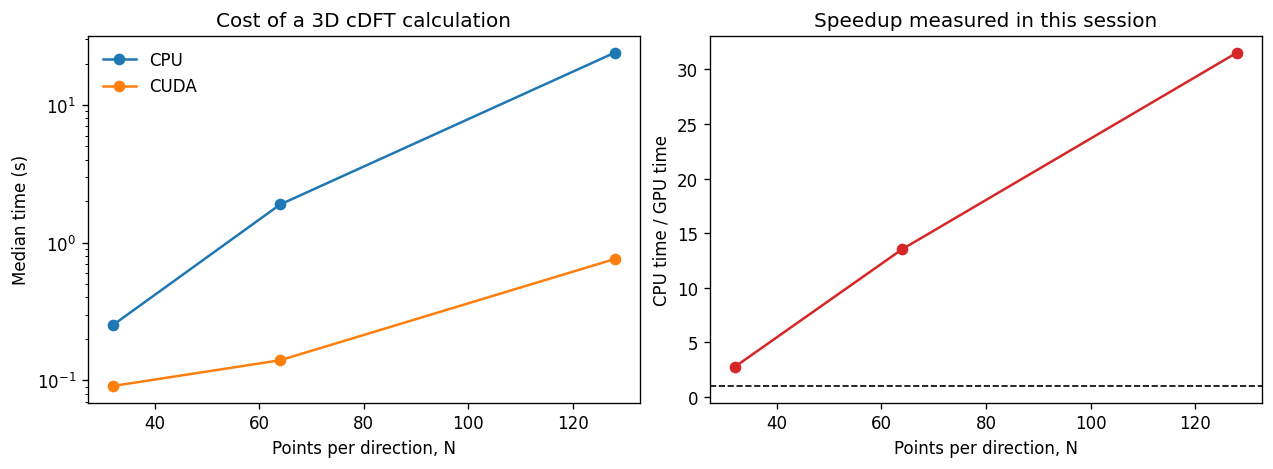

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
for device in dispositivos:
    t = resumo_gpu.query("Device == @device and Converged")
    ax[0].plot(t["N"], t["Tempo_s"], "o-", label=device.upper())
ax[0].set(xlabel="Points per direction, N", ylabel="Median time (s)",
          yscale="log", title="Cost of a 3D cDFT calculation")
ax[0].legend(frameon=False)
tempos_gpu = resumo_gpu[resumo_gpu["Converged"]].pivot(index="N", columns="Device", values="Tempo_s")
if "cuda" in tempos_gpu:
    ax[1].plot(tempos_gpu.index, tempos_gpu["cpu"]/tempos_gpu["cuda"], "o-", color="C3")
    ax[1].axhline(1, color="k", ls="--", lw=1)
else:
    ax[1].text(0.5, 0.5, "Enable a GPU in Colab to measure speedup", transform=ax[1].transAxes, ha="center", wrap=True)
ax[1].set(xlabel="Points per direction, N", ylabel="CPU time / GPU time", title="Speedup measured in this session")
plt.show()


# Part G — Application to research

## 19. Adapting the workflow to your research

Before changing the CIF and clicking “Run all,” record:

| Decision | Minimum question |
|---|---|
| adsorbate | does a single LJ site represent the molecule over this $T,p$ range? |
| solid | is the structure rigid, periodic, and orthogonal? |
| force field | are parameters available for all elements and is there a defensible combining rule? |
| functional | does MFA, WDA, or MMFA change the conclusion? |
| grid/cutoff | does the observable converge as they are refined? |
| solver | is the error below 1 and is the state independent of the guess? |
| adsorption | absolute or excess? What reference volume? |

Other possibilities in the repository examples include hard walls, cylinders, radial distribution functions, other MOFs/ZIFs, and amorphous carbons.

### 19.1 Final checklist

- [ ] Code commit recorded;
- [ ] Units and parameters referenced;
- [ ] EOS and functional consistent in the uniform limit;
- [ ] Force field and combining rule documented;
- [ ] Grid, cutoff, and solver tested;
- [ ] `converged=True` and final error reported;
- [ ] Absolute/excess adsorption defined;
- [ ] Comparison with independent simulation or experiment;
- [ ] Limitations that may change the conclusion discussed.

If you can explain this line, you are ready to adapt the calculation:

```text
fluid → grid → geometry → Vext → T → bulk → guess → solver → profile/isotherm
```

### 19.2 Verification of this revision

Revision 6 was tested locally on CPU. Verified parameters and results appear in the cell outputs; versions and thread count are recorded at the beginning.

- ASE carbon slab, minimum-image convention, LJ summation, and three density controls: 1D Steele, 1D finite layers, and 3D atomistic slab.
- MOF isotherm with 44 pressures, including 900 bar, and convergence diagnostics at each point.
- Picard, Anderson, and ABC-FIRE on the same 3D slab, always starting from the bulk and showing unsmoothed histories.
- CPU benchmark at 32³, 64³, and 128³. The GPU curve is calculated automatically when CUDA is available.

This revision was not tested on a GPU or directly in the Colab interface. Each title is now in its own text cell, with no other title in the same cell, to prevent the Colab table of contents from grouping a section and subsection. The unchanged RDF, N₂, and fine MOF-isotherm studies were not fully rerun in this revision.

### 19.3 Essential references

1. E. do A. Soares, A. G. Barreto, and F. W. Tavares, *Fluid Phase Equilibria* (2023), 113887. [DOI](https://doi.org/10.1016/j.fluid.2023.113887)
2. Y. Rosenfeld, *Physical Review Letters* 63 (1989), 980. [DOI](https://doi.org/10.1103/PhysRevLett.63.980)
3. Y.-X. Yu and J. Wu, *Journal of Chemical Physics* 117 (2002), 10156. [DOI](https://doi.org/10.1063/1.1520530)
4. H. Hansen-Goos and R. Roth, *Journal of Physics: Condensed Matter* 18 (2006), 8413. [DOI](https://doi.org/10.1088/0953-8984/18/37/002)
5. R. Roth et al., *Journal of Physics: Condensed Matter* 14 (2002), 12063. [DOI](https://doi.org/10.1088/0953-8984/14/46/313)
6. G. Shen, X. Ji, and X. Lu, *Journal of Chemical Physics* 138 (2013), 224706. [DOI](https://doi.org/10.1063/1.4808160)
7. E. do A. Soares, A. G. Barreto, and F. W. Tavares, *Fluid Phase Equilibria* 542–543 (2021), 113095. [DOI](https://doi.org/10.1016/j.fluid.2021.113095)
8. J. K. Johnson, J. A. Zollweg, and K. E. Gubbins, *Molecular Physics* 78 (1993), 591. [DOI](https://doi.org/10.1080/00268979300100411)
9. W. A. Steele, *Surface Science* 36 (1973), 317. [DOI](https://doi.org/10.1016/0039-6028(73)90264-1)
10. M. G. Martin and J. I. Siepmann, TraPPE-UA, *J. Phys. Chem. B* 102 (1998), 2569. [DOI](https://doi.org/10.1021/jp972543+)
11. S. L. Mayo, B. D. Olafson, and W. A. Goddard, DREIDING, *J. Phys. Chem.* 94 (1990), 8897. [DOI](https://doi.org/10.1021/j100389a010)
12. A. K. Rappé et al., UFF, *JACS* 114 (1992), 10024. [DOI](https://doi.org/10.1021/ja00051a040)
13. D. G. Anderson, *Journal of the ACM* 12 (1965), 547. [DOI](https://doi.org/10.1145/321296.321305)
14. E. Bitzek et al., FIRE, *Physical Review Letters* 97 (2006), 170201. [DOI](https://doi.org/10.1103/PhysRevLett.97.170201)

Code and examples: [PyDFTlj](https://github.com/elvissoares/PyDFTlj), GPL-3.0 license.

15. I. K. Snook and W. van Megen, *Solvation forces in simple dense fluids. I* (1980). [DOI](https://doi.org/10.1063/1.439489).
16. P. I. Ravikovitch et al., *Langmuir* 16 (2000), 2311–2320. [DOI](https://doi.org/10.1021/la991011c).
17. A. Fortini and M. Dijkstra, *J. Phys.: Condens. Matter* 18 (2006), L371. [DOI](https://doi.org/10.1088/0953-8984/18/28/L02).
18. M. Schmidt and H. Löwen, *Phys. Rev. E* 55 (1997), 7228. [DOI](https://doi.org/10.1103/PhysRevE.55.7228).
19. L. Verlet, *Phys. Rev.* 165 (1968), 201. [DOI](https://doi.org/10.1103/PhysRev.165.201).